# Chargement des datasets Olist

Ce notebook charge tous les fichiers CSV du projet dans des DataFrames pandas.

In [36]:


# ============================================================================
# ÉTAPE 1 : IMPORTATION DES PACKAGES NÉCESSAIRES
# ============================================================================

from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Configuration des graphiques
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("=" * 90)
print(" " * 20 + "ANALYSE PROFESSIONNELLE DE SYSTHEME DE PRICING DYNAMIQUE(E-COMMERCE)")
print(" " * 30 + "Machine Learning Pipeline")
print("=" * 90)

                    ANALYSE PROFESSIONNELLE DE SYSTHEME DE PRICING DYNAMIQUE(E-COMMERCE)
                              Machine Learning Pipeline


In [2]:
base_path = Path('.')

dataset_files = {
    'customers': 'olist_customers_dataset.csv',
    'geolocation': 'olist_geolocation_dataset.csv',
    'order_items': 'olist_order_items_dataset.csv',
    'order_payments': 'olist_order_payments_dataset.csv',
    'order_reviews': 'olist_order_reviews_dataset.csv',
    'orders': 'olist_orders_dataset.csv',
    'products': 'olist_products_dataset.csv',
    'sellers': 'olist_sellers_dataset.csv',
    'category_translation': 'product_category_name_translation.csv'
}

date_columns = {
    'orders': [
        'order_purchase_timestamp',
        'order_approved_at',
        'order_delivered_carrier_date',
        'order_delivered_customer_date',
        'order_estimated_delivery_date'
    ],
    'order_reviews': ['review_creation_date', 'review_answer_timestamp']
}

datasets = {}

for name, filename in dataset_files.items():
    file_path = base_path / filename
    if not file_path.exists():
        raise FileNotFoundError(f'Fichier introuvable: {file_path}')

    datasets[name] = pd.read_csv(file_path, parse_dates=date_columns.get(name))

print('Chargement termine avec succes.')

Chargement termine avec succes.


In [3]:
for name, df in datasets.items():
    print(f'\n=== {name} ===')
    print(f'Shape: {df.shape[0]} lignes, {df.shape[1]} colonnes')
    print(f'Valeurs manquantes: {int(df.isna().sum().sum())}')


=== customers ===
Shape: 99441 lignes, 5 colonnes
Valeurs manquantes: 0

=== geolocation ===
Shape: 1000163 lignes, 5 colonnes
Valeurs manquantes: 0

=== order_items ===
Shape: 112650 lignes, 7 colonnes
Valeurs manquantes: 0

=== order_payments ===
Shape: 103886 lignes, 5 colonnes
Valeurs manquantes: 0

=== order_reviews ===
Shape: 99224 lignes, 7 colonnes
Valeurs manquantes: 145903

=== orders ===
Shape: 99441 lignes, 8 colonnes
Valeurs manquantes: 4908

=== products ===
Shape: 32951 lignes, 9 colonnes
Valeurs manquantes: 2448

=== sellers ===
Shape: 3095 lignes, 4 colonnes
Valeurs manquantes: 0

=== category_translation ===
Shape: 71 lignes, 2 colonnes
Valeurs manquantes: 0


In [4]:
# Construction d'un dataset consolide au niveau ligne de commande (order item)
orders = datasets['orders'].copy()
customers = datasets['customers'].copy()
order_items = datasets['order_items'].copy()
products = datasets['products'].copy()
sellers = datasets['sellers'].copy()
order_payments = datasets['order_payments'].copy()
order_reviews = datasets['order_reviews'].copy()

# Agregations pour garder une ligne de paiement / avis par commande
payments_agg = (
    order_payments
    .groupby('order_id', as_index=False)
    .agg(
        payment_sequential_max=('payment_sequential', 'max'),
        payment_installments_max=('payment_installments', 'max'),
        payment_value_total=('payment_value', 'sum'),
        payment_type_nunique=('payment_type', 'nunique')
    )
)

reviews_agg = (
    order_reviews
    .sort_values('review_answer_timestamp')
    .groupby('order_id', as_index=False)
    .agg(
        review_score_mean=('review_score', 'mean'),
        review_creation_date_max=('review_creation_date', 'max'),
        review_answer_timestamp_max=('review_answer_timestamp', 'max')
    )
)

# Jointures principales
olist_full = (
    orders
    .merge(customers, on='customer_id', how='left')
    .merge(order_items, on='order_id', how='left')
    .merge(products, on='product_id', how='left')
    .merge(sellers, on='seller_id', how='left')
    .merge(payments_agg, on='order_id', how='left')
    .merge(reviews_agg, on='order_id', how='left')
)

print('Dataset consolide cree avec succes.')
print(f'Shape: {olist_full.shape[0]} lignes, {olist_full.shape[1]} colonnes')
olist_full.head()

Dataset consolide cree avec succes.
Shape: 113425 lignes, 36 colonnes


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,seller_zip_code_prefix,seller_city,seller_state,payment_sequential_max,payment_installments_max,payment_value_total,payment_type_nunique,review_score_mean,review_creation_date_max,review_answer_timestamp_max
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,9350.0,maua,SP,3.0,1.0,38.71,2.0,4.0,2017-10-11,2017-10-12 03:43:48
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,...,31570.0,belo horizonte,SP,1.0,1.0,141.46,1.0,4.0,2018-08-08,2018-08-08 18:37:50
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,14840.0,guariba,SP,1.0,3.0,179.12,1.0,5.0,2018-08-18,2018-08-22 19:07:58
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,59296,...,31842.0,belo horizonte,MG,1.0,1.0,72.20,1.0,5.0,2017-12-03,2017-12-05 19:21:58
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,9195,...,8752.0,mogi das cruzes,SP,1.0,1.0,28.62,1.0,5.0,2018-02-17,2018-02-18 13:02:51


In [5]:
print(f"\n DIMENSIONS DU DATASET")
print(f"   • Nombre de lignes: {olist_full.shape[0]:,}")
print(f"   • Nombre de colonnes: {olist_full.shape[1]}")
print(f"   • Noms de colonnes: {olist_full.columns}")

 
print(f"\n APERÇU DES PREMIÈRES LIGNES :")
olist_full.head(10)


 DIMENSIONS DU DATASET
   • Nombre de lignes: 113,425
   • Nombre de colonnes: 36
   • Noms de colonnes: Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'customer_unique_id', 'customer_zip_code_prefix', 'customer_city',
       'customer_state', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value',
       'product_category_name', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm',
       'seller_zip_code_prefix', 'seller_city', 'seller_state',
       'payment_sequential_max', 'payment_installments_max',
       'payment_value_total', 'payment_type_nunique', 'review_score_mean',
       'review_creation_date_max', 'review_answer_timestamp_max'],
      dtype='s

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,seller_zip_code_prefix,seller_city,seller_state,payment_sequential_max,payment_installments_max,payment_value_total,payment_type_nunique,review_score_mean,review_creation_date_max,review_answer_timestamp_max
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,9350.0,maua,SP,3.0,1.0,38.71,2.0,4.0,2017-10-11,2017-10-12 03:43:48
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,...,31570.0,belo horizonte,SP,1.0,1.0,141.46,1.0,4.0,2018-08-08,2018-08-08 18:37:50
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,14840.0,guariba,SP,1.0,3.0,179.12,1.0,5.0,2018-08-18,2018-08-22 19:07:58
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,59296,...,31842.0,belo horizonte,MG,1.0,1.0,72.20,1.0,5.0,2017-12-03,2017-12-05 19:21:58
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,9195,...,8752.0,mogi das cruzes,SP,1.0,1.0,28.62,1.0,5.0,2018-02-17,2018-02-18 13:02:51
5,a4591c265e18cb1dcee52889e2d8acc3,503740e9ca751ccdda7ba28e9ab8f608,delivered,2017-07-09 21:57:05,2017-07-09 22:10:13,2017-07-11 14:58:04,2017-07-26 10:57:55,2017-08-01,80bb27c7c16e8f973207a5086ab329e2,86320,...,7112.0,guarulhos,SP,1.0,6.0,175.26,1.0,4.0,2017-07-27,2017-07-27 22:48:30
6,136cce7faa42fdb2cefd53fdc79a6098,ed0271e0b7da060a393796590e7b737a,invoiced,2017-04-11 12:22:08,2017-04-13 13:25:17,NaT,NaT,2017-05-09,36edbb3fb164b1f16485364b6fb04c73,98900,...,5455.0,sao paulo,SP,1.0,1.0,65.95,1.0,2.0,2017-05-13,2017-05-13 20:25:42
7,6514b8ad8028c9f2cc2374ded245783f,9bdf08b4b3b52b5526ff42d37d47f222,delivered,2017-05-16 13:10:30,2017-05-16 13:22:11,2017-05-22 10:07:46,2017-05-26 12:55:51,2017-06-07,932afa1e708222e5821dac9cd5db4cae,26525,...,12940.0,atibaia,SP,1.0,3.0,75.16,1.0,5.0,2017-05-27,2017-05-28 02:59:57
8,76c6e866289321a7c93b82b54852dc33,f54a9f0e6b351c431402b8461ea51999,delivered,2017-01-23 18:29:09,2017-01-25 02:50:47,2017-01-26 14:16:31,2017-02-02 14:08:10,2017-03-06,39382392765b6dc74812866ee5ee92a7,99655,...,13720.0,sao jose do rio pardo,SP,1.0,1.0,35.95,1.0,1.0,2017-02-03,2017-02-05 01:58:35
9,e69bfb5eb88e0ed6a785585b27e16dbf,31ad1d1b63eb9962463f764d4e6e0c9d,delivered,2017-07-29 11:55:02,2017-07-29 12:05:32,2017-08-10 19:45:24,2017-08-16 17:14:30,2017-08-23,299905e3934e9e181bfb2e164dd4b4f8,18075,...,8577.0,itaquaquecetuba,SP,2.0,1.0,169.76,2.0,5.0,2017-08-17,2017-08-18 01:47:32


In [6]:
# types de données
print(f"\n TYPES DE DONNÉES :")
olist_full.dtypes




 TYPES DE DONNÉES :


order_id                                    str
customer_id                                 str
order_status                                str
order_purchase_timestamp         datetime64[us]
order_approved_at                datetime64[us]
order_delivered_carrier_date     datetime64[us]
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date    datetime64[us]
customer_unique_id                          str
customer_zip_code_prefix                  int64
customer_city                               str
customer_state                              str
order_item_id                           float64
product_id                                  str
seller_id                                   str
shipping_limit_date                         str
price                                   float64
freight_value                           float64
product_category_name                       str
product_name_lenght                     float64
product_description_lenght              

In [7]:
#streamlit run .\simulateur_web.py
print(olist_full["product_category_name"].value_counts().head(10))

product_category_name
cama_mesa_banho           11115
beleza_saude               9670
esporte_lazer              8641
moveis_decoracao           8334
informatica_acessorios     7827
utilidades_domesticas      6964
relogios_presentes         5991
telefonia                  4545
ferramentas_jardim         4347
automotivo                 4235
Name: count, dtype: int64


In [8]:
#statistiques descriptives
print(f"\n STATISTIQUES DESCRIPTIVES :")
olist_full.describe()


 STATISTIQUES DESCRIPTIVES :


,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_zip_code_prefix,order_item_id,price,freight_value,product_name_lenght,...,product_height_cm,product_width_cm,seller_zip_code_prefix,payment_sequential_max,payment_installments_max,payment_value_total,payment_type_nunique,review_score_mean,review_creation_date_max,review_answer_timestamp_max
count,113425,113264,111457,110196,113425,113425.000000,112650.000000,112650.000000,112650.000000,111047.000000,...,112632.000000,112632.000000,112650.000000,113422.000000,113422.000000,113422.000000,113422.000000,112464.000000,112464,112464
mean,2017-12-31 12:25:41.686480,2017-12-31 22:40:56.664121,2018-01-05 02:17:27.942515,2018-01-14 13:25:24.023938,2018-01-24 08:22:34.875909,35102.472965,1.197834,120.653739,19.990320,48.775978,...,16.593766,22.996546,24439.170431,1.044956,3.016611,180.482857,1.022103,4.017589,2018-01-13 07:09:52.925736,2018-01-16 10:44:12.581599
min,2016-09-04 21:15:19,2016-09-15 12:16:38,2016-10-08 10:34:01,2016-10-11 13:46:32,2016-09-30 00:00:00,1003.000000,1.000000,0.850000,0.000000,5.000000,...,2.000000,6.000000,1001.000000,1.000000,0.000000,0.000000,1.000000,1.000000,2016-10-02 00:00:00,2016-10-07 18:32:28
25%,2017-09-13 11:05:49,2017-09-13 20:25:10.500000,2017-09-18 20:37:00,2017-09-26 20:09:44.500000,2017-10-04 00:00:00,11250.000000,1.000000,39.900000,13.080000,42.000000,...,8.000000,15.000000,6429.000000,1.000000,1.000000,65.680000,1.000000,4.000000,2017-09-26 00:00:00,2017-09-28 06:47:21.750000
50%,2018-01-19 10:37:45,2018-01-19 16:59:52.500000,2018-01-24 18:44:33,2018-02-02 20:57:23,2018-02-15 00:00:00,24320.000000,1.000000,74.990000,16.260000,52.000000,...,13.000000,20.000000,13568.000000,1.000000,2.000000,114.400000,1.000000,5.000000,2018-02-02 00:00:00,2018-02-05 13:03:16
75%,2018-05-04 14:22:16,2018-05-04 18:31:38.500000,2018-05-08 13:20:00,2018-05-15 20:09:21.500000,2018-05-25 00:00:00,59020.000000,1.000000,134.900000,21.150000,57.000000,...,20.000000,30.000000,27930.000000,1.000000,4.000000,195.360000,1.000000,5.000000,2018-05-16 00:00:00,2018-05-20 13:05:08.750000
max,2018-10-17 17:30:18,2018-09-03 17:40:06,2018-09-11 19:48:28,2018-10-17 13:22:46,2018-11-12 00:00:00,99990.000000,21.000000,6735.000000,409.680000,76.000000,...,105.000000,118.000000,99730.000000,29.000000,24.000000,13664.080000,2.000000,5.000000,2018-08-31 00:00:00,2018-10-29 12:27:35
std,NaN,NaN,NaN,NaN,NaN,29864.919733,0.705124,183.633928,15.806405,10.025581,...,13.443483,11.707268,27596.030909,0.386987,2.802682,273.548227,0.147020,1.398415,NaN,NaN


In [9]:
# ============================================================================
# ÉTAPE 3 : NETTOYAGE DES DONNÉES
# ============================================================================
# Valeurs manquantes
print("\n ANALYSE DES VALEURS MANQUANTES :")
olist_full.isnull().sum()



 ANALYSE DES VALEURS MANQUANTES :


order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 161
order_delivered_carrier_date     1968
order_delivered_customer_date    3229
order_estimated_delivery_date       0
customer_unique_id                  0
customer_zip_code_prefix            0
customer_city                       0
customer_state                      0
order_item_id                     775
product_id                        775
seller_id                         775
shipping_limit_date               775
price                             775
freight_value                     775
product_category_name            2378
product_name_lenght              2378
product_description_lenght       2378
product_photos_qty               2378
product_weight_g                  793
product_length_cm                 793
product_height_cm                 793
product_width_cm                  793
seller_zip_c

In [10]:
# Vérifie le volume de valeurs manquantes (sans suppression globale)
print("\n ANALYSE DES VALEURS MANQUANTES :")
missing = olist_full.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

if missing.empty:
    print("   Aucune valeur manquante - Dataset complet !")
else:
    missing_pct = (missing / len(olist_full) * 100).round(2)
    missing_report = pd.DataFrame({
        'missing_count': missing,
        'missing_pct': missing_pct
    })
    print(f"   {int(missing.sum())} valeurs manquantes détectées")
    display(missing_report)


 ANALYSE DES VALEURS MANQUANTES :
   27912 valeurs manquantes détectées


,missing_count,missing_pct
order_delivered_customer_date,3229,2.85
product_name_lenght,2378,2.10
product_category_name,2378,2.10
product_photos_qty,2378,2.10
product_description_lenght,2378,2.10
order_delivered_carrier_date,1968,1.74
review_answer_timestamp_max,961,0.85
review_creation_date_max,961,0.85
review_score_mean,961,0.85
product_height_cm,793,0.70


In [11]:
# Imputation des colonnes catégorielles
cat_cols = olist_full.select_dtypes(include=['object', 'category', 'str']).columns
for col in cat_cols:
    olist_full.loc[:, col] = olist_full[col].fillna('unknown')

# Imputation des colonnes numériques
num_cols = olist_full.select_dtypes(include=['int64', 'float64']).columns
for col in num_cols:
    olist_full.loc[:, col] = olist_full[col].fillna(olist_full[col].median())

# Vérification rapide après imputation
print("Valeurs manquantes restantes après imputation (top 10) :")
print(olist_full.isnull().sum().sort_values(ascending=False).head(10))

Valeurs manquantes restantes après imputation (top 10) :
order_delivered_customer_date    3229
order_delivered_carrier_date     1968
review_answer_timestamp_max       961
review_creation_date_max          961
order_approved_at                 161
order_status                        0
customer_id                         0
order_id                            0
order_purchase_timestamp            0
customer_zip_code_prefix            0
dtype: int64


In [12]:
# Conversion des colonnes de date en format datetime
# Utilisation de l'assignation directe (compatible pandas 3 où str != object)
date_cols = [col for col in olist_full.columns if ("date" in col or "timestamp" in col)]
for col in date_cols:
    olist_full[col] = pd.to_datetime(olist_full[col], errors="coerce")

# Règles métier d'imputation des dates pour supprimer les NA restants
# 1) Une commande approuvée manquante prend la date d'achat
olist_full['order_approved_at'] = olist_full['order_approved_at'].fillna(
    olist_full['order_purchase_timestamp']
)

# 2) Date transporteur manquante: fallback sur la date d'approbation
olist_full['order_delivered_carrier_date'] = olist_full['order_delivered_carrier_date'].fillna(
    olist_full['order_approved_at']
)

# 3) Date livrée client manquante: fallback sur la date estimée
olist_full['order_delivered_customer_date'] = olist_full['order_delivered_customer_date'].fillna(
    olist_full['order_estimated_delivery_date']
)

# 4) Dates d'avis manquantes: fallback sur date de livraison client
olist_full['review_creation_date_max'] = olist_full['review_creation_date_max'].fillna(
    olist_full['order_delivered_customer_date']
)
olist_full['review_answer_timestamp_max'] = olist_full['review_answer_timestamp_max'].fillna(
    olist_full['review_creation_date_max']
)

# 5) Limite d'expédition manquante: fallback sur la date d'achat
olist_full['shipping_limit_date'] = olist_full['shipping_limit_date'].fillna(
    olist_full['order_purchase_timestamp']
)

print("NA restants sur colonnes de dates après règles métier:")
print(olist_full[date_cols].isnull().sum().sort_values(ascending=False))

NA restants sur colonnes de dates après règles métier:
order_purchase_timestamp         0
order_delivered_carrier_date     0
order_delivered_customer_date    0
order_estimated_delivery_date    0
shipping_limit_date              0
review_creation_date_max         0
review_answer_timestamp_max      0
dtype: int64


In [13]:
# Vérification finale des valeurs manquantes
missing_final = olist_full.isnull().sum().sort_values(ascending=False)
print("Top 10 des NA restants (toutes colonnes) :")
print(missing_final.head(10))

print("\nContrôle ciblé des colonnes de dates :")
date_cols = [col for col in olist_full.columns if ("date" in col or "timestamp" in col)]
print(olist_full[date_cols].isnull().sum().sort_values(ascending=False))

Top 10 des NA restants (toutes colonnes) :
order_id                         0
customer_id                      0
order_status                     0
order_purchase_timestamp         0
order_approved_at                0
order_delivered_carrier_date     0
order_delivered_customer_date    0
order_estimated_delivery_date    0
customer_unique_id               0
customer_zip_code_prefix         0
dtype: int64

Contrôle ciblé des colonnes de dates :
order_purchase_timestamp         0
order_delivered_carrier_date     0
order_delivered_customer_date    0
order_estimated_delivery_date    0
shipping_limit_date              0
review_creation_date_max         0
review_answer_timestamp_max      0
dtype: int64


In [14]:
# Vérification des types de données après conversion
olist_full.dtypes

order_id                                    str
customer_id                                 str
order_status                                str
order_purchase_timestamp         datetime64[us]
order_approved_at                datetime64[us]
order_delivered_carrier_date     datetime64[us]
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date    datetime64[us]
customer_unique_id                          str
customer_zip_code_prefix                  int64
customer_city                               str
customer_state                              str
order_item_id                           float64
product_id                                  str
seller_id                                   str
shipping_limit_date              datetime64[us]
price                                   float64
freight_value                           float64
product_category_name                       str
product_name_lenght                     float64
product_description_lenght              

In [15]:
# Doublons
print(f"\n ANALYSE DES DOUBLONS :")
print(olist_full.duplicated().sum())


 ANALYSE DES DOUBLONS :
0


In [16]:
# Suppression des doublons avant l'analyse des outliers
n_duplicates = olist_full.duplicated().sum()
if n_duplicates > 0:
    olist_full = olist_full.drop_duplicates().copy()
    print(f"\n {n_duplicates} doublons supprimés")
else:
    print("\n Aucun doublon à supprimer")

# Outliers
print(f"\n DÉTECTION DES OUTLIERS (IQR) :")
numeric_cols = olist_full.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    Q1 = olist_full[col].quantile(0.25)
    Q3 = olist_full[col].quantile(0.75)
    IQR = Q3 - Q1

    if pd.isna(IQR) or IQR == 0:
        continue

    outliers = olist_full[
        (olist_full[col] < Q1 - 1.5 * IQR) |
        (olist_full[col] > Q3 + 1.5 * IQR)
    ]
    if len(outliers) > 0:
        print(f"   • {col:25s} : {len(outliers):4d} outliers ({len(outliers)/len(olist_full)*100:5.2f}%)")

print("\n DÉCISION : conservation des transactions atypiques")


 Aucun doublon à supprimer

 DÉTECTION DES OUTLIERS (IQR) :
   • price                     : 8465 outliers ( 7.46%)
   • freight_value             : 12134 outliers (10.70%)
   • product_name_lenght       : 1240 outliers ( 1.09%)
   • product_description_lenght : 7277 outliers ( 6.42%)
   • product_photos_qty        : 3073 outliers ( 2.71%)
   • product_weight_g          : 15807 outliers (13.94%)
   • product_length_cm         : 3617 outliers ( 3.19%)
   • product_height_cm         : 7670 outliers ( 6.76%)
   • product_width_cm          : 2563 outliers ( 2.26%)
   • seller_zip_code_prefix    : 17454 outliers (15.39%)
   • payment_installments_max  : 8052 outliers ( 7.10%)
   • payment_value_total       : 9285 outliers ( 8.19%)
   • review_score_mean         : 18530 outliers (16.34%)

 DÉCISION : conservation des transactions atypiques


In [17]:
# Enregistrement du dataset nettoyé
olist_full.to_csv('olist_full_cleaned.csv', index=False)

In [18]:
# Vérification finale des colonnes
print(olist_full.columns)

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'customer_unique_id', 'customer_zip_code_prefix', 'customer_city',
       'customer_state', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value',
       'product_category_name', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm',
       'seller_zip_code_prefix', 'seller_city', 'seller_state',
       'payment_sequential_max', 'payment_installments_max',
       'payment_value_total', 'payment_type_nunique', 'review_score_mean',
       'review_creation_date_max', 'review_answer_timestamp_max'],
      dtype='str')


In [19]:
olist_full.dtypes

order_id                                    str
customer_id                                 str
order_status                                str
order_purchase_timestamp         datetime64[us]
order_approved_at                datetime64[us]
order_delivered_carrier_date     datetime64[us]
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date    datetime64[us]
customer_unique_id                          str
customer_zip_code_prefix                  int64
customer_city                               str
customer_state                              str
order_item_id                           float64
product_id                                  str
seller_id                                   str
shipping_limit_date              datetime64[us]
price                                   float64
freight_value                           float64
product_category_name                       str
product_name_lenght                     float64
product_description_lenght              

In [20]:
# Vérification finale des valeurs manquantes
olist_full.isnull().sum()

order_id                         0
customer_id                      0
order_status                     0
order_purchase_timestamp         0
order_approved_at                0
order_delivered_carrier_date     0
order_delivered_customer_date    0
order_estimated_delivery_date    0
customer_unique_id               0
customer_zip_code_prefix         0
customer_city                    0
customer_state                   0
order_item_id                    0
product_id                       0
seller_id                        0
shipping_limit_date              0
price                            0
freight_value                    0
product_category_name            0
product_name_lenght              0
product_description_lenght       0
product_photos_qty               0
product_weight_g                 0
product_length_cm                0
product_height_cm                0
product_width_cm                 0
seller_zip_code_prefix           0
seller_city                      0
seller_state        

# Analyse Exploratoire & Visualisations — Olist Pricing Dynamique

Chargement du dataset nettoyé `olist_full_cleaned.csv` et analyse visuelle complète.

Dataset chargé : 113,425 lignes × 36 colonnes


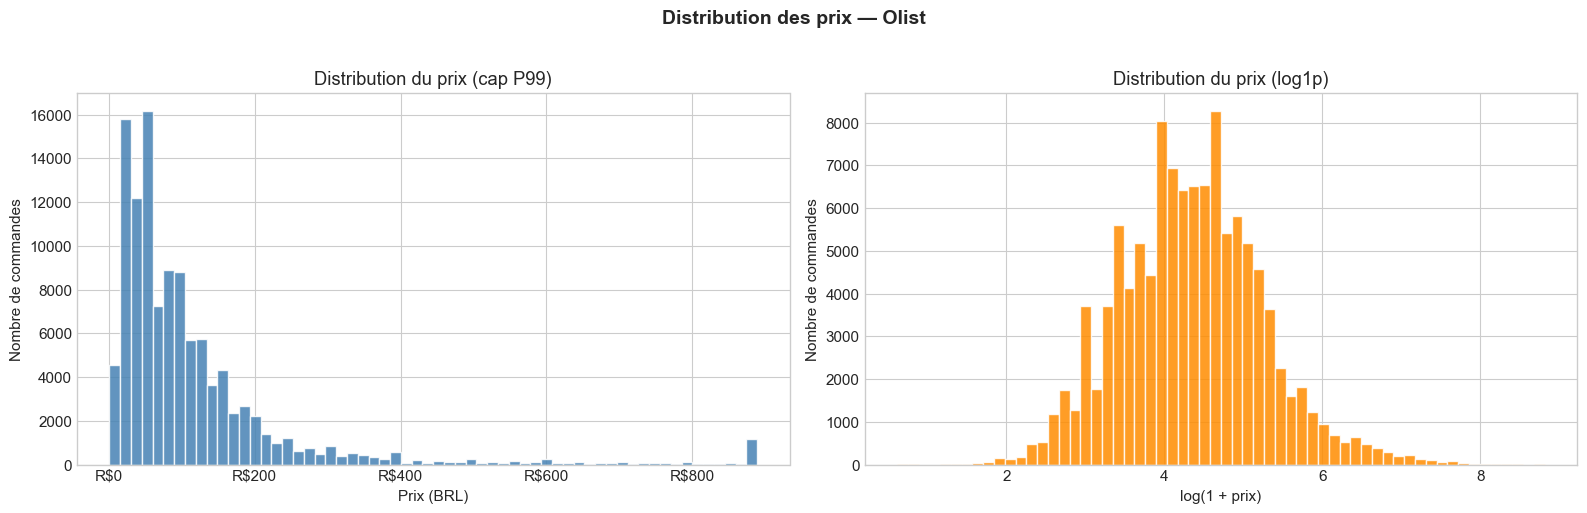

count    113425.00
mean        120.34
std         183.04
min           0.85
25%          39.90
50%          74.99
75%         134.00
max        6735.00
Name: price, dtype: float64


In [21]:

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11

df = pd.read_csv('olist_full_cleaned.csv', parse_dates=[
    'order_purchase_timestamp', 'order_approved_at',
    'order_delivered_carrier_date', 'order_delivered_customer_date',
    'order_estimated_delivery_date', 'shipping_limit_date',
    'review_creation_date_max', 'review_answer_timestamp_max'
])

print(f'Dataset chargé : {df.shape[0]:,} lignes × {df.shape[1]} colonnes')
df.head(3)

# ============================================================================
# DISTRIBUTION DU PRIX
# ============================================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].hist(df['price'].clip(upper=df['price'].quantile(0.99)),
             bins=60, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Distribution du prix (cap P99)')
axes[0].set_xlabel('Prix (BRL)')
axes[0].set_ylabel('Nombre de commandes')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x:,.0f}'))

axes[1].hist(np.log1p(df['price']), bins=60,
             color='darkorange', edgecolor='white', alpha=0.85)
axes[1].set_title('Distribution du prix (log1p)')
axes[1].set_xlabel('log(1 + prix)')
axes[1].set_ylabel('Nombre de commandes')

plt.suptitle('Distribution des prix — Olist', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(df['price'].describe().round(2))

## 2. Prix moyen par catégorie de produit (Top 20)

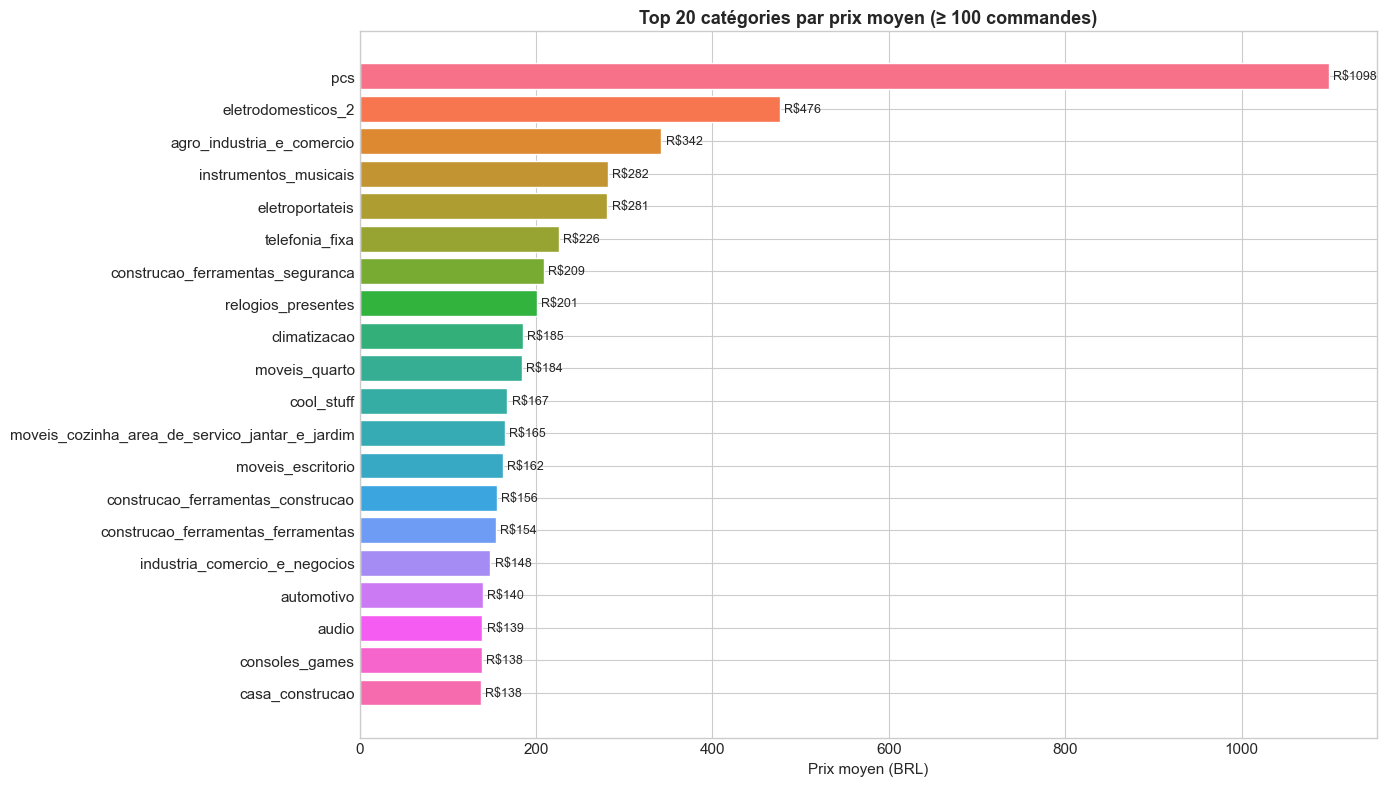

In [22]:
# ============================================================================
# PRIX MOYEN PAR CATÉGORIE (TOP 20)
# ============================================================================
cat_price = (
    df.groupby('product_category_name')['price']
    .agg(['mean', 'median', 'count'])
    .query('count >= 100')
    .sort_values('mean', ascending=False)
    .head(20)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(14, 8))
bars = ax.barh(cat_price['product_category_name'], cat_price['mean'],
               color=sns.color_palette('husl', len(cat_price)), edgecolor='white')

for bar, val in zip(bars, cat_price['mean']):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height() / 2,
            f'R${val:.0f}', va='center', fontsize=9)

ax.set_xlabel('Prix moyen (BRL)')
ax.set_title('Top 20 catégories par prix moyen (≥ 100 commandes)',
             fontsize=13, fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 3. Évolution mensuelle du chiffre d'affaires

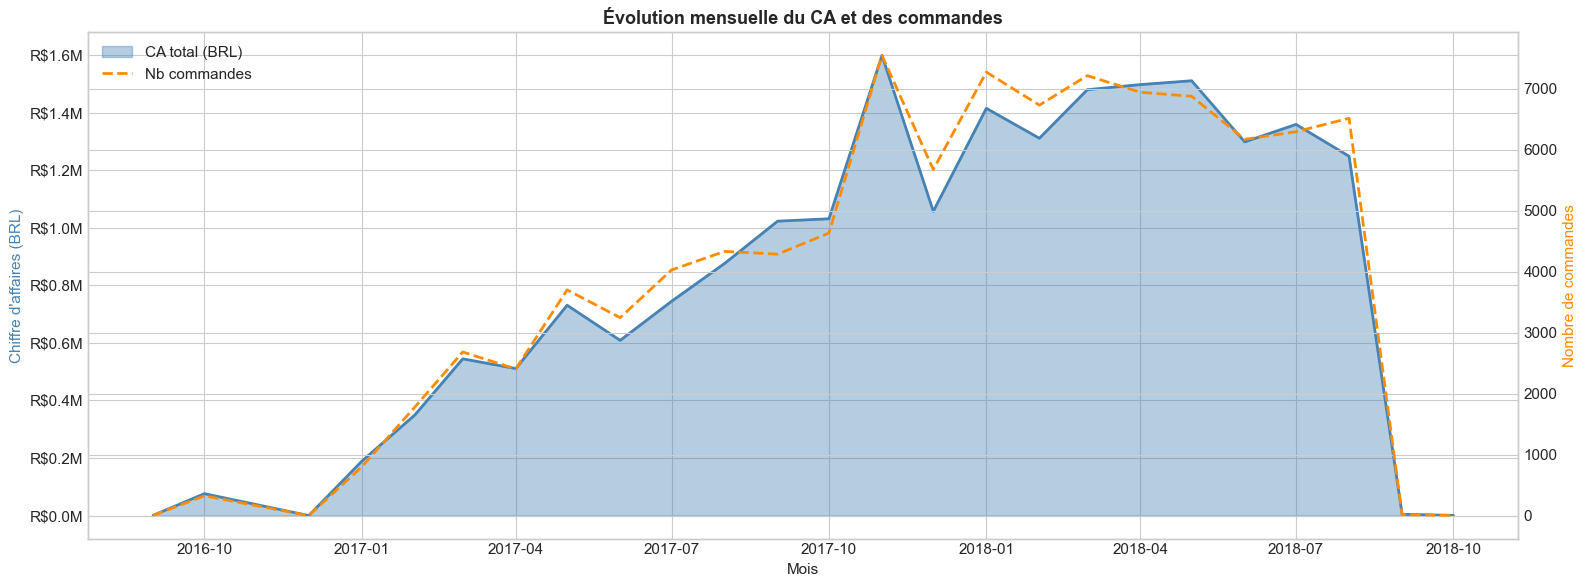

In [23]:
# ============================================================================
# ÉVOLUTION TEMPORELLE DES VENTES
# ============================================================================
df['annee_mois'] = df['order_purchase_timestamp'].dt.to_period('M')

monthly = (
    df.groupby('annee_mois')
    .agg(nb_commandes=('order_id', 'nunique'),
         ca_total=('payment_value_total', 'sum'))
    .reset_index()
)
monthly['annee_mois_dt'] = monthly['annee_mois'].dt.to_timestamp()

fig, ax1 = plt.subplots(figsize=(16, 6))
ax2 = ax1.twinx()

ax1.fill_between(monthly['annee_mois_dt'], monthly['ca_total'],
                 alpha=0.4, color='steelblue', label='CA total (BRL)')
ax1.plot(monthly['annee_mois_dt'], monthly['ca_total'],
         color='steelblue', linewidth=2)
ax2.plot(monthly['annee_mois_dt'], monthly['nb_commandes'],
         color='darkorange', linewidth=2, linestyle='--', label='Nb commandes')

ax1.set_ylabel("Chiffre d'affaires (BRL)", color='steelblue')
ax2.set_ylabel('Nombre de commandes', color='darkorange')
ax1.set_xlabel('Mois')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x/1e6:.1f}M'))

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
ax1.set_title("Évolution mensuelle du CA et des commandes",
              fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Matrice de corrélation des variables numériques

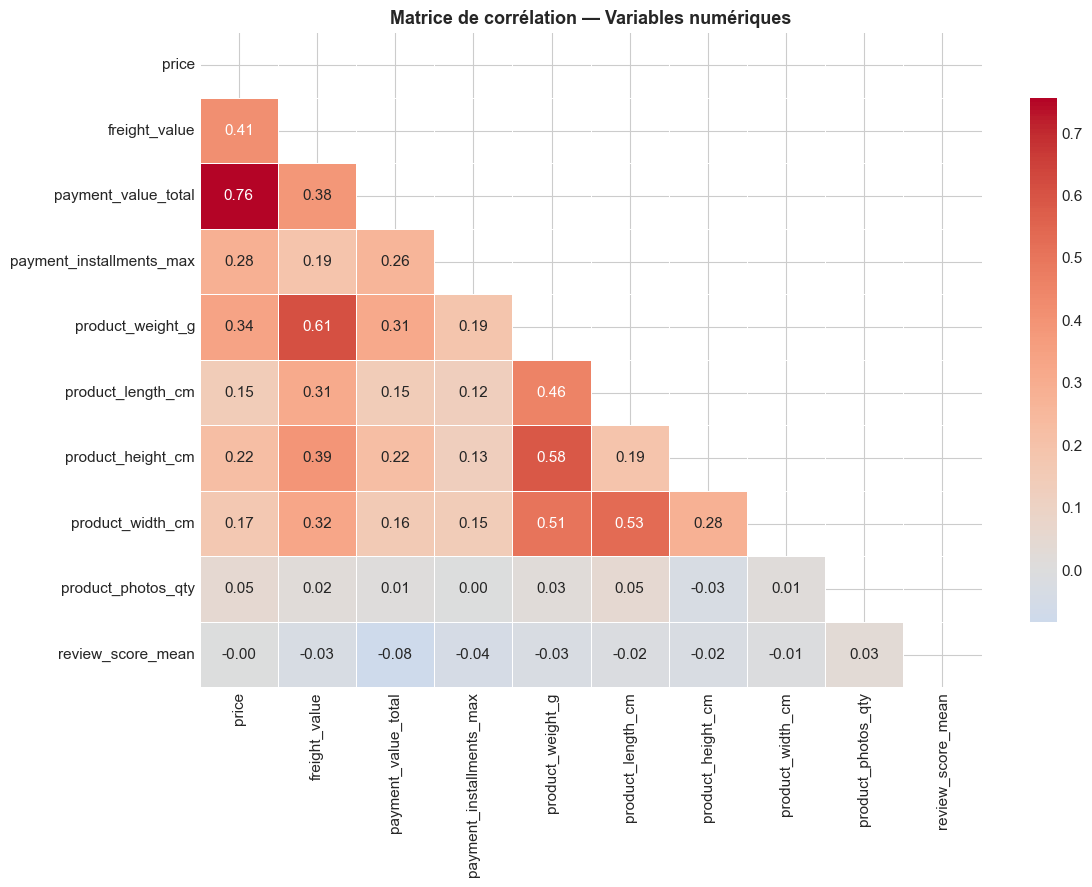

In [24]:
# ============================================================================
# MATRICE DE CORRÉLATION
# ============================================================================
num_features = [
    'price', 'freight_value', 'payment_value_total', 'payment_installments_max',
    'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm',
    'product_photos_qty', 'review_score_mean'
]
num_features = [c for c in num_features if c in df.columns]

corr = df[num_features].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Matrice de corrélation — Variables numériques',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 10. Nombre de commandes par mode de paiement

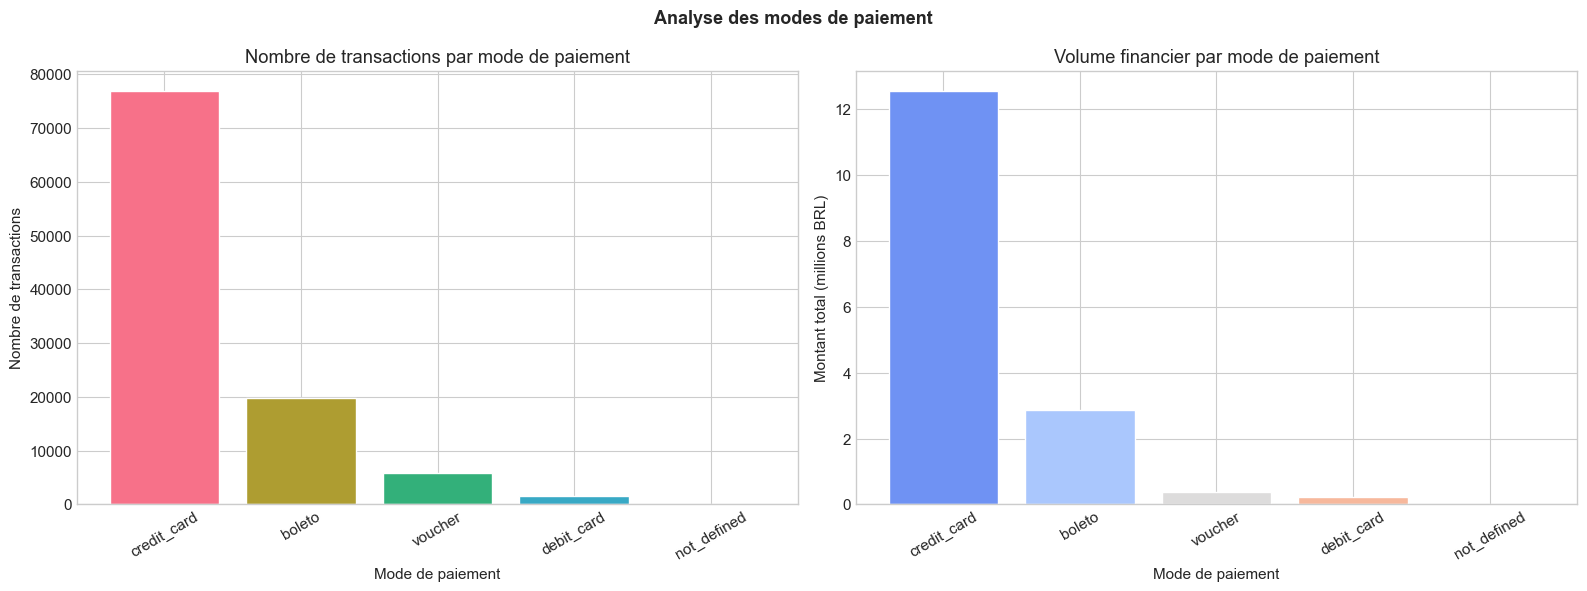

In [25]:
# ============================================================================
# MODE DE PAIEMENT
# ============================================================================
payment_df = pd.read_csv('olist_order_payments_dataset.csv')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

pay_count = payment_df['payment_type'].value_counts()
axes[0].bar(pay_count.index, pay_count.values,
            color=sns.color_palette('husl', len(pay_count)), edgecolor='white')
axes[0].set_title('Nombre de transactions par mode de paiement')
axes[0].set_xlabel('Mode de paiement')
axes[0].set_ylabel('Nombre de transactions')
axes[0].tick_params(axis='x', rotation=30)

pay_value = payment_df.groupby('payment_type')['payment_value'].sum().sort_values(ascending=False)
axes[1].bar(pay_value.index, pay_value.values / 1e6,
            color=sns.color_palette('coolwarm', len(pay_value)), edgecolor='white')
axes[1].set_title('Volume financier par mode de paiement')
axes[1].set_xlabel('Mode de paiement')
axes[1].set_ylabel('Montant total (millions BRL)')
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle('Analyse des modes de paiement', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Répartition des commandes par état (Top 15)

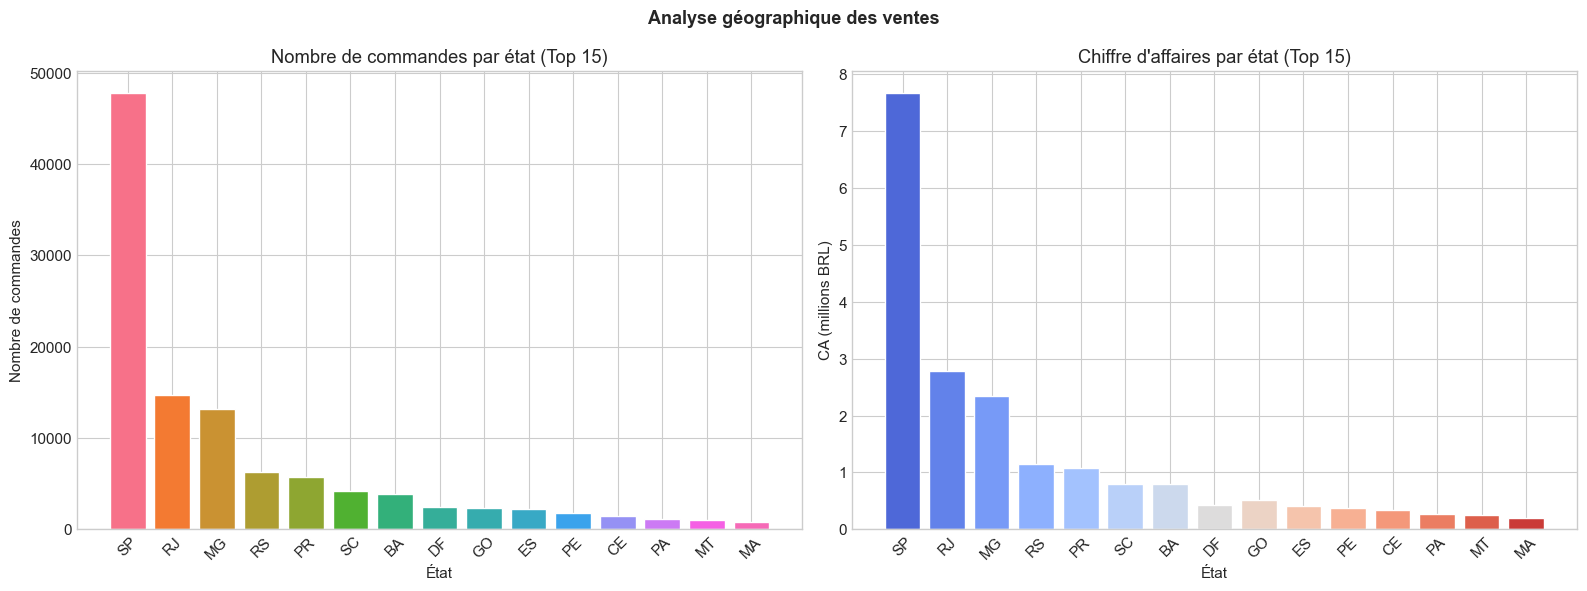

In [26]:
# ============================================================================
# TOP ÉTATS PAR VOLUME DE COMMANDES ET CA
# ============================================================================
state_stats = (
    df.groupby('customer_state')
    .agg(nb_commandes=('order_id', 'count'),
         ca_total=('payment_value_total', 'sum'),
         prix_median=('price', 'median'))
    .sort_values('nb_commandes', ascending=False)
    .head(15)
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].bar(state_stats['customer_state'], state_stats['nb_commandes'],
            color=sns.color_palette('husl', len(state_stats)), edgecolor='white')
axes[0].set_title('Nombre de commandes par état (Top 15)')
axes[0].set_xlabel('État')
axes[0].set_ylabel('Nombre de commandes')
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(state_stats['customer_state'], state_stats['ca_total'] / 1e6,
            color=sns.color_palette('coolwarm', len(state_stats)), edgecolor='white')
axes[1].set_title("Chiffre d'affaires par état (Top 15)")
axes[1].set_xlabel('État')
axes[1].set_ylabel('CA (millions BRL)')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Analyse géographique des ventes', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [27]:
# ============================================================================
# EXTRACTION DES VARIABLES PERTINENTES POUR LE PRICING DYNAMIQUE
# ============================================================================

# Base de travail
olist_features = olist_full.copy()

# ---------------------------------------------------------------------------
# 1) FEATURES SAISONNALITÉ
# ---------------------------------------------------------------------------
olist_features['annee_mois'] = olist_features['order_purchase_timestamp'].dt.to_period('M').astype(str)
olist_features['mois'] = olist_features['order_purchase_timestamp'].dt.month
olist_features['trimestre'] = olist_features['order_purchase_timestamp'].dt.quarter
olist_features['jour_semaine'] = olist_features['order_purchase_timestamp'].dt.dayofweek
olist_features['is_weekend'] = (olist_features['jour_semaine'] >= 5).astype(int)

# Encodage cyclique du mois
olist_features['mois_sin'] = np.sin(2 * np.pi * olist_features['mois'] / 12)
olist_features['mois_cos'] = np.cos(2 * np.pi * olist_features['mois'] / 12)

# ---------------------------------------------------------------------------
# 2) FEATURES PANIER MOYEN
# ---------------------------------------------------------------------------
# Panier au niveau commande
order_basket = (
    olist_features
    .groupby(['order_id', 'customer_unique_id'], as_index=False)
    .agg(
        nb_items_commande=('order_item_id', 'count'),
        panier_commande=('price', 'sum'),
        fret_commande=('freight_value', 'sum')
    )
)
order_basket['panier_commande_avec_fret'] = order_basket['panier_commande'] + order_basket['fret_commande']

# Historique client basé sur les paniers
customer_history = (
    order_basket
    .groupby('customer_unique_id', as_index=False)
    .agg(
        nb_commandes_client=('order_id', 'nunique'),
        panier_moyen_client=('panier_commande_avec_fret', 'mean'),
        depense_totale_client=('panier_commande_avec_fret', 'sum')
    )
)

# ---------------------------------------------------------------------------
# 3) FEATURES DÉLAIS
# ---------------------------------------------------------------------------
olist_features['delai_approbation_h'] = (
    olist_features['order_approved_at'] - olist_features['order_purchase_timestamp']
).dt.total_seconds() / 3600

olist_features['delai_livraison_j'] = (
    olist_features['order_delivered_customer_date'] - olist_features['order_purchase_timestamp']
).dt.days

olist_features['retard_livraison_j'] = (
    olist_features['order_delivered_customer_date'] - olist_features['order_estimated_delivery_date']
).dt.days

# ---------------------------------------------------------------------------
# 4) FEATURE ÉLASTICITÉ DE LA DEMANDE (proxy par catégorie et mois)
# ---------------------------------------------------------------------------
elasticity_base = (
    olist_features
    .groupby(['product_category_name', 'annee_mois'], as_index=False)
    .agg(
        demande_qte=('order_id', 'count'),
        prix_moyen_categorie_mois=('price', 'mean')
    )
    .sort_values(['product_category_name', 'annee_mois'])
)

elasticity_base['pct_change_demande'] = (
    elasticity_base
    .groupby('product_category_name')['demande_qte']
    .pct_change()
)
elasticity_base['pct_change_prix'] = (
    elasticity_base
    .groupby('product_category_name')['prix_moyen_categorie_mois']
    .pct_change()
)

# Evite division par zero ou valeurs infinies
elasticity_base['elasticite_demande'] = (
    elasticity_base['pct_change_demande'] /
    elasticity_base['pct_change_prix'].replace(0, np.nan)
)
elasticity_base['elasticite_demande'] = (
    elasticity_base['elasticite_demande']
    .replace([np.inf, -np.inf], np.nan)
)

# ---------------------------------------------------------------------------
# 5) DATASET FINAL DES FEATURES
# ---------------------------------------------------------------------------
selected_cols = [
    'order_id',
    'customer_unique_id',
    'product_id',
    'product_category_name',
    'price',
    'freight_value',
    'payment_value_total',
    'review_score_mean',
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_customer_date',
    'order_estimated_delivery_date',
    'annee_mois',
    'mois',
    'trimestre',
    'jour_semaine',
    'is_weekend',
    'mois_sin',
    'mois_cos',
    'delai_approbation_h',
    'delai_livraison_j',
    'retard_livraison_j'
]

pricing_features = (
    olist_features[selected_cols]
    .merge(order_basket[['order_id', 'nb_items_commande', 'panier_commande', 'fret_commande', 'panier_commande_avec_fret']],
           on='order_id', how='left')
    .merge(customer_history, on='customer_unique_id', how='left')
    .merge(elasticity_base[['product_category_name', 'annee_mois', 'elasticite_demande']],
           on=['product_category_name', 'annee_mois'], how='left')
)

# Imputation des NA résiduels des features dérivées
for col in ['delai_approbation_h', 'delai_livraison_j', 'retard_livraison_j', 'elasticite_demande']:
    pricing_features[col] = pricing_features[col].fillna(pricing_features[col].median())

print('Extraction terminée avec features avancées.')
print(f"Shape features: {pricing_features.shape[0]} lignes, {pricing_features.shape[1]} colonnes")
print('Nouvelles features clés: elasticite_demande, saisonnalite, panier moyen')
pricing_features.head()

Extraction terminée avec features avancées.
Shape features: 113425 lignes, 30 colonnes
Nouvelles features clés: elasticite_demande, saisonnalite, panier moyen


,order_id,customer_unique_id,product_id,product_category_name,price,freight_value,payment_value_total,review_score_mean,order_purchase_timestamp,order_approved_at,...,delai_livraison_j,retard_livraison_j,nb_items_commande,panier_commande,fret_commande,panier_commande_avec_fret,nb_commandes_client,panier_moyen_client,depense_totale_client,elasticite_demande
0,e481f51cbdc54678b7cc49136f2d6af7,7c396fd4830fd04220f754e42b4e5bff,87285b34884572647811a353c7ac498a,utilidades_domesticas,29.99,8.72,38.71,4.0,2017-10-02 10:56:33,2017-10-02 11:07:15,...,8,-8,1,29.99,8.72,38.71,2,41.41,82.82,0.539114
1,53cdb2fc8bc7dce0b6741e2150273451,af07308b275d755c9edb36a90c618231,595fac2a385ac33a80bd5114aec74eb8,perfumaria,118.70,22.76,141.46,4.0,2018-07-24 20:41:37,2018-07-26 03:24:27,...,13,-6,1,118.70,22.76,141.46,1,141.46,141.46,-0.347065
2,47770eb9100c2d0c44946d9cf07ec65d,3a653a41f6f9fc3d2a113cf8398680e8,aa4383b373c6aca5d8797843e5594415,automotivo,159.90,19.22,179.12,5.0,2018-08-08 08:38:49,2018-08-08 08:55:23,...,9,-18,1,159.90,19.22,179.12,1,179.12,179.12,-1.736216
3,949d5b44dbf5de918fe9c16f97b45f8a,7c142cf63193a1473d2e66489a9ae977,d0b61bfb1de832b15ba9d266ca96e5b0,pet_shop,45.00,27.20,72.20,5.0,2017-11-18 19:28:06,2017-11-18 19:45:59,...,13,-13,1,45.00,27.20,72.20,1,72.20,72.20,5.533090
4,ad21c59c0840e6cb83a9ceb5573f8159,72632f0f9dd73dfee390c9b22eb56dd6,65266b2da20d04dbe00c5c2d3bb7859e,papelaria,19.90,8.72,28.62,5.0,2018-02-13 21:18:39,2018-02-13 22:20:29,...,2,-10,1,19.90,8.72,28.62,1,28.62,28.62,2.169033


In [28]:
# Export des variables pertinentes
pricing_features.to_csv('olist_pricing_features.csv', index=False)

print("Fichier créé: olist_pricing_features.csv")
print("Aperçu des variables extraites:")
print(pricing_features.columns.tolist())

Fichier créé: olist_pricing_features.csv
Aperçu des variables extraites:
['order_id', 'customer_unique_id', 'product_id', 'product_category_name', 'price', 'freight_value', 'payment_value_total', 'review_score_mean', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'annee_mois', 'mois', 'trimestre', 'jour_semaine', 'is_weekend', 'mois_sin', 'mois_cos', 'delai_approbation_h', 'delai_livraison_j', 'retard_livraison_j', 'nb_items_commande', 'panier_commande', 'fret_commande', 'panier_commande_avec_fret', 'nb_commandes_client', 'panier_moyen_client', 'depense_totale_client', 'elasticite_demande']


## ÉTAPE 5 — ENVIRONNEMENT DE REINFORCEMENT LEARNING (PRICING DYNAMIQUE)

### Définition de l'espace d'état (State Space)

L'agent observe à chaque pas de temps les variables suivantes :

| Groupe | Variables |
|---|---|
| **Prix** | `price`, `freight_value`, `panier_moyen_client` |
| **Demande** | `elasticite_demande`, `nb_items_commande` |
| **Historique client** | `nb_commandes_client`, `depense_totale_client`, `review_score_mean` |
| **Saisonnalité** | `mois_sin`, `mois_cos`, `trimestre`, `is_weekend` |
| **Délais** | `delai_approbation_h`, `delai_livraison_j`, `retard_livraison_j` |

Le vecteur d'état est normalisé (StandardScaler) pour stabiliser l'apprentissage.

In [29]:
# Dependances minimales pour un DQN from-scratch (sans Stable-Baselines)
import importlib
import subprocess
import sys


def ensure_package(import_name: str, pip_name: str | None = None) -> None:
    try:
        importlib.import_module(import_name)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", pip_name or import_name])


ensure_package("torch")
ensure_package("sklearn", "scikit-learn")
ensure_package("tqdm")
ensure_package("ipywidgets")  # Evite le warning IProgress dans tqdm.auto

print("Packages verifies/installes: torch, scikit-learn, tqdm, ipywidgets")

Packages verifies/installes: torch, scikit-learn, tqdm, ipywidgets


## ETAPE 6 - DQN (Deep Q-Network) pour le pricing dynamique

Objectif: apprendre une politique de variation de prix discrete qui maximise un profit attendu, en s'appuyant sur les features de demande, saisonnalite, delais et qualite.

- Action space: multipliers de prix plus contrastes
- State space: features normalisees + prix courant
- Reward: profit simule avec effet d'elasticite + penalites de volatilite/reputation, puis normalisee
- Algorithme: Double DQN avec replay buffer et target network

## Définition formelle de l'environnement RL — MDP de pricing dynamique

Le choix retenu est un **DQN (Deep Q-Network)** avec trois raffinements adaptés au pricing dynamique :

- **Double DQN** pour limiter le biais de surestimation des Q-valeurs.
- **Architecture dueling** pour séparer la valeur d'état $V(s)$ de l'avantage d'action $A(s,a)$.
- **Prioritized Experience Replay (PER)** pour rééchantillonner plus souvent les transitions informatives.

L'agent apprend à fixer les prix en interagissant avec un **Processus de Décision de Markov (MDP)** défini par le quadruplet $(\mathcal{S},\, \mathcal{A},\, \mathcal{T},\, \mathcal{R})$.

---

### État $s_t \in \mathcal{S}$

Le réseau reçoit en entrée un vecteur de **8 features normalisées** (StandardScaler) à chaque pas $t$ :

| Groupe | Variables |
|---|---|
| **Prix & Logistique** | `price`, `freight_value` |
| **Demande historique** | `base_demand`, `elasticite_demande` |
| **Qualité historique** | `historical_review_score` |
| **Saisonnalité** | `mois_sin`, `mois_cos`, `is_weekend` |

Donc l'entrée du réseau a une dimension : **8 neurones**.

---

### Actions $a_t \in \mathcal{A}$ — 5 actions discrètes

La sortie du réseau correspond à **5 Q-valeurs**, une par action de pricing :

| ID | Nom | Variation prix |
|:---:|---|:---:|
| 0 | `DECREASE_LARGE` | **−30 %** |
| 1 | `DECREASE_SMALL` | **−15 %** |
| 2 | `MAINTAIN` | **0 %** |
| 3 | `INCREASE_SMALL` | **+15 %** |
| 4 | `INCREASE_LARGE` | **+30 %** |

La couche de sortie a donc une dimension : **5 neurones**.

---

### Structure du réseau Q

L'architecture effectivement implémentée est :

- **Entrée** : 8 features d'état.
- **Tronc partagé** : `Linear(8, 256) -> ReLU -> LayerNorm -> Linear(256, 256) -> ReLU`.
- **Branche valeur** : `Linear(256, 128) -> ReLU -> Linear(128, 1)`.
- **Branche avantage** : `Linear(256, 128) -> ReLU -> Linear(128, 5)`.
- **Sortie finale** : $Q(s,a) = V(s) + A(s,a) - \frac{1}{|\mathcal{A}|}\sum_{a'} A(s,a')$.

---

### Paramètres d'apprentissage

Les hyperparamètres principaux du DQN sont :

- **Learning rate** : $3 \times 10^{-4}$
- **Discount factor** : $\gamma = 0.99$
- **Politique d'exploration** : **epsilon-greedy**
- **Epsilon initial** : $1.0$
- **Epsilon final** : $0.05$
- **Décroissance d'epsilon** : $0.995$ par épisode
- **Reheat d'exploration** : $0.22$ en cas de plateau
- **Batch size** : 256
- **Soft update target network** : $\tau = 0.005$

---

### Récompense composite $r_t \in \mathcal{R}$

$$r_t^{\text{raw}} = \underbrace{\alpha \cdot \pi_t}_{\text{profit}} \;+\; \underbrace{\beta \cdot \text{sat}_t}_{\text{satisfaction client}} \;-\; \underbrace{\gamma \cdot \nu_t}_{\text{volatilité + churn}}$$

$$r_t = \text{clip}\!\left(\frac{r_t^{\text{raw}}}{R_{\sigma}},\; -R_{\max},\; +R_{\max}\right) \qquad \alpha=0.50,\;\beta=0.30,\;\gamma=0.20$$

| Composante | Formule utilisée |
|---|---|
| **Profit brut** $\pi_t$ | $(p_t - c_t)\times d_t$ avec $d_t = d_0 \cdot \exp(\varepsilon\cdot\Delta p/p_0)$ borné |
| **Satisfaction** $\text{sat}_t$ | Bonus/malus dépendant de `historical_review_score` et du sens de variation de prix |
| **Volatilité + churn** $\nu_t$ | Pénalité sur $|\Delta p|\times p_0$ et surcharge en cas de sur-pricing vs prix de référence |

---

### Dynamique de transition

Le prix suit une **mean-reversion** vers les données historiques :

$$p_{t+1} = (1-\mu)\cdot p_t^{\text{new}} + \mu\cdot p_t^{\text{hist}}, \qquad \mu=0.4$$

Les épisodes ont une longueur fixe $T = 128$ steps, avec un démarrage aléatoire pour couvrir la diversité des contextes.

In [30]:
import random
from dataclasses import dataclass
from typing import ClassVar

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import trange

# ------------------------------------------------------------------
# 1) Configuration experimentale
# ------------------------------------------------------------------
SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f"Device utilise: {DEVICE}")


# ------------------------------------------------------------------
# 2) Preparation des donnees RL a partir de pricing_features
#    Version anti-leakage: uniquement des signaux historiques
# ------------------------------------------------------------------
assert "pricing_features" in globals(), (
    "pricing_features doit etre defini avant cette cellule."
)

df_rl = pricing_features.copy()

required_cols = [
    "price",
    "freight_value",
    "review_score_mean",
    "mois_sin",
    "mois_cos",
    "trimestre",
    "is_weekend",
    "product_category_name",
    "order_purchase_timestamp",
]

missing_cols = [c for c in required_cols if c not in df_rl.columns]
if missing_cols:
    raise ValueError(f"Colonnes manquantes pour le DQN: {missing_cols}")

df_rl = df_rl[required_cols].copy()
df_rl["order_purchase_timestamp"] = pd.to_datetime(df_rl["order_purchase_timestamp"], errors="coerce")
df_rl = df_rl.dropna(subset=["order_purchase_timestamp"]).copy()

num_cols = [c for c in df_rl.columns if c not in ("product_category_name", "order_purchase_timestamp")]
for c in num_cols:
    df_rl[c] = pd.to_numeric(df_rl[c], errors="coerce")
    df_rl[c] = df_rl[c].replace([np.inf, -np.inf], np.nan)

# Imputation conservative
df_rl["price"] = df_rl["price"].fillna(df_rl["price"].median())
df_rl["freight_value"] = df_rl["freight_value"].fillna(df_rl["freight_value"].median())
df_rl["review_score_mean"] = df_rl["review_score_mean"].fillna(df_rl["review_score_mean"].median())
df_rl["mois_sin"] = df_rl["mois_sin"].fillna(0.0)
df_rl["mois_cos"] = df_rl["mois_cos"].fillna(1.0)
df_rl["trimestre"] = df_rl["trimestre"].fillna(df_rl["trimestre"].median())
df_rl["is_weekend"] = df_rl["is_weekend"].fillna(0.0)

# Tri temporel obligatoire
df_rl = df_rl.sort_values("order_purchase_timestamp").reset_index(drop=True)
df_rl["annee_mois"] = df_rl["order_purchase_timestamp"].dt.to_period("M").astype(str)

# Historique categorie-mois et variables laguees pour eviter fuite de cible
cat_month = (
    df_rl.groupby(["product_category_name", "annee_mois"], as_index=False)
    .agg(
        monthly_orders=("price", "size"),
        monthly_price=("price", "median"),
        monthly_review=("review_score_mean", "mean"),
    )
    .sort_values(["product_category_name", "annee_mois"])
)

cat_month["lag_monthly_orders"] = (
    cat_month.groupby("product_category_name")["monthly_orders"].shift(1)
)
cat_month["lag_monthly_price"] = (
    cat_month.groupby("product_category_name")["monthly_price"].shift(1)
)
cat_month["lag_monthly_review"] = (
    cat_month.groupby("product_category_name")["monthly_review"].shift(1)
)

cat_month["pct_change_orders"] = cat_month.groupby("product_category_name")["monthly_orders"].pct_change()
cat_month["pct_change_price"] = cat_month.groupby("product_category_name")["monthly_price"].pct_change()
cat_month["elasticity_raw"] = cat_month["pct_change_orders"] / cat_month["pct_change_price"].replace(0, np.nan)
cat_month["elasticity_hist"] = cat_month.groupby("product_category_name")["elasticity_raw"].shift(1)

merge_cols = [
    "product_category_name",
    "annee_mois",
    "lag_monthly_orders",
    "lag_monthly_price",
    "lag_monthly_review",
    "elasticity_hist",
]

df_rl = df_rl.merge(cat_month[merge_cols], on=["product_category_name", "annee_mois"], how="left")

# Base demand purement historique (pas de payment_value_total, pas de nb_items_commande)
global_orders_med = float(cat_month["monthly_orders"].median()) if len(cat_month) else 1.0
df_rl["base_demand"] = df_rl["lag_monthly_orders"].fillna(global_orders_med).clip(lower=0.5, upper=500.0)

# Prix de reference historique
price_med = float(df_rl["price"].median())
df_rl["historical_ref_price"] = df_rl["lag_monthly_price"].fillna(price_med).clip(lower=1.0)

# Score satisfaction historique
review_med = float(df_rl["review_score_mean"].median())
df_rl["historical_review_score"] = df_rl["lag_monthly_review"].fillna(review_med).clip(1.0, 5.0)

# Elasticite economiquement plausible: toujours negative
e_med = float(cat_month["elasticity_raw"].replace([np.inf, -np.inf], np.nan).dropna().median())
if np.isnan(e_med):
    e_med = -1.2
df_rl["elasticite_demande"] = df_rl["elasticity_hist"].fillna(e_med)
df_rl["elasticite_demande"] = -np.abs(df_rl["elasticite_demande"]).clip(lower=0.20, upper=3.50)

# Cout unitaire estime par categorie (quantile bas des prix)
cat_cost_proxy = (
    df_rl.groupby("product_category_name")["price"].quantile(0.35).rename("cat_cost_proxy")
)
df_rl = df_rl.merge(cat_cost_proxy, on="product_category_name", how="left")
df_rl["estimated_unit_cost"] = np.minimum(df_rl["cat_cost_proxy"], 0.92 * df_rl["price"]).clip(lower=1.0)

# Etat causal: uniquement variables disponibles au moment de decision
state_cols = [
    "price",
    "freight_value",
    "base_demand",
    "elasticite_demande",
    "historical_review_score",
    "mois_sin",
    "mois_cos",
    "is_weekend",
]

split_idx = int(0.8 * len(df_rl))
train_df = df_rl.iloc[:split_idx].reset_index(drop=True)
test_df = df_rl.iloc[split_idx:].reset_index(drop=True)

scaler = StandardScaler()
scaler.fit(train_df[state_cols])

action_multipliers = np.array([-0.30, -0.15, 0.00, 0.15, 0.30], dtype=np.float32)

print(f"Train size: {len(train_df)} | Test size: {len(test_df)}")
print(f"Nb actions: {len(action_multipliers)} -> {action_multipliers.tolist()}")
print("Etat causal actif (anti-triche):", state_cols)


# ------------------------------------------------------------------
# 3) Environnement RL de pricing dynamique (anti-triche)
# ------------------------------------------------------------------
class DynamicPricingEnv:
    ACTION_NAMES: ClassVar[list[str]] = [
        "DECREASE_LARGE (-30%)",
        "DECREASE_SMALL (-15%)",
        "MAINTAIN (0%)",
        "INCREASE_SMALL (+15%)",
        "INCREASE_LARGE (+30%)",
    ]

    def __init__(
        self,
        data: pd.DataFrame,
        scaler: StandardScaler,
        state_cols: list,
        action_multipliers: np.ndarray,
        *,
        episode_len: int = 128,
        mean_reversion: float = 0.4,
        reward_scale: float = 8_000.0,
        reward_clip: float = 5.0,
        alpha_profit: float = 0.50,
        beta_satisfaction: float = 0.30,
        gamma_volatility: float = 0.20,
        sat_score_threshold: float = 3.8,
        overprice_soft_cap: float = 1.35,
        overprice_hard_cap: float = 1.60,
        repeat_increase_penalty: float = 0.75,
        seed: int = 42,
    ) -> None:
        if not np.isclose(alpha_profit + beta_satisfaction + gamma_volatility, 1.0, atol=1e-6):
            raise ValueError("Les poids alpha/beta/gamma doivent sommer a 1.")

        self.data = data.reset_index(drop=True)
        self.scaler = scaler
        self.state_cols = list(state_cols)
        self.action_multipliers = action_multipliers
        self.n_actions = len(action_multipliers)
        self.episode_len = episode_len
        self.mean_reversion = mean_reversion
        self.reward_scale = reward_scale
        self.reward_clip = reward_clip
        self.alpha_profit = alpha_profit
        self.beta_satisfaction = beta_satisfaction
        self.gamma_volatility = gamma_volatility
        self.sat_score_threshold = sat_score_threshold
        self.overprice_soft_cap = overprice_soft_cap
        self.overprice_hard_cap = overprice_hard_cap
        self.repeat_increase_penalty = repeat_increase_penalty

        self.rng = np.random.default_rng(seed)
        self.idx = 0
        self.t = 0
        self.current_price = 0.0
        self.last_action = 2

    @property
    def observation_dim(self) -> int:
        return len(self.state_cols)

    @property
    def max_start_index(self) -> int:
        return max(1, len(self.data) - self.episode_len - 1)

    def action_name(self, action: int) -> str:
        if not (0 <= action < self.n_actions):
            raise ValueError(f"Action invalide: {action}")
        return self.ACTION_NAMES[action]

    def _build_state(self, row: pd.Series, current_price: float) -> np.ndarray:
        state_row = row[self.state_cols].copy()
        state_row["price"] = current_price
        return self.scaler.transform(state_row.to_frame().T).astype(np.float32).squeeze(0)

    def _realized_demand(
        self,
        base_demand: float,
        elasticity: float,
        base_price: float,
        new_price: float,
    ) -> float:
        rel_change = (new_price - base_price) / (base_price + 1e-6)
        demand_multiplier = float(np.exp(elasticity * rel_change))
        demand_multiplier = float(np.clip(demand_multiplier, 0.03, 3.00))
        return base_demand * demand_multiplier

    def _satisfaction_bonus(self, historical_review: float, delta: float, base_price: float) -> float:
        if historical_review >= self.sat_score_threshold:
            return 0.03 * (historical_review - self.sat_score_threshold + 1.0) * abs(delta) * base_price
        if delta > 0:
            return -0.60 * (self.sat_score_threshold - historical_review) * delta * base_price
        return 0.12 * (self.sat_score_threshold - historical_review) * abs(delta) * base_price

    def reset(self, start_idx: int | None = None) -> np.ndarray:
        if start_idx is None:
            self.idx = int(self.rng.integers(0, self.max_start_index))
        else:
            if not (0 <= start_idx < self.max_start_index):
                raise ValueError(
                    f"start_idx hors bornes: {start_idx} (doit etre dans [0, {self.max_start_index - 1}])"
                )
            self.idx = int(start_idx)

        self.t = 0
        self.last_action = 2
        row = self.data.iloc[self.idx]
        self.current_price = float(row["price"] )
        return self._build_state(row, self.current_price)

    def step(self, action: int):
        if not (0 <= action < self.n_actions):
            raise ValueError(f"Action invalide: {action}")

        row = self.data.iloc[self.idx]
        base_price = float(row["price"] )
        elasticity = float(np.clip(row["elasticite_demande"], -3.5, -0.2))
        base_demand = float(np.clip(row["base_demand"], 0.5, 500.0))
        unit_cost = float(np.clip(row["estimated_unit_cost"], 1.0, 0.97 * max(1.0, base_price)))
        historical_review = float(np.clip(row["historical_review_score"], 1.0, 5.0))
        ref_price = float(max(1.0, row["historical_ref_price"]))

        delta = float(self.action_multipliers[action])
        new_price = max(1.0, self.current_price * (1.0 + delta))

        demand = self._realized_demand(base_demand, elasticity, base_price, new_price)
        gross_profit = (new_price - unit_cost) * demand

        sat_bonus = self._satisfaction_bonus(historical_review, delta, base_price)
        vol_penalty = abs(delta) * base_price

        overpricing_ratio = max(0.0, new_price / (ref_price + 1e-6) - 1.0)
        churn_penalty = overpricing_ratio * base_demand * 0.50

        # Penalisation anti-shortcut: escalade de prix non contextuelle
        repeat_increase = float(action >= 3 and self.last_action >= 3)
        repeated_increase_penalty = repeat_increase * self.repeat_increase_penalty * base_price * max(0.4, abs(elasticity))

        # Soft cap progressif puis hard cap severement penalise
        soft_overprice = max(0.0, new_price / (ref_price + 1e-6) - self.overprice_soft_cap)
        hard_overprice = max(0.0, new_price / (ref_price + 1e-6) - self.overprice_hard_cap)
        overprice_soft_penalty = soft_overprice * base_demand * 1.2
        overprice_hard_penalty = hard_overprice * base_demand * 4.0

        total_market_penalty = churn_penalty + repeated_increase_penalty + overprice_soft_penalty + overprice_hard_penalty

        raw_reward = (
            self.alpha_profit * gross_profit
            + self.beta_satisfaction * sat_bonus
            - self.gamma_volatility * (vol_penalty + total_market_penalty)
        )
        scaled_reward = float(np.clip(raw_reward / self.reward_scale, -self.reward_clip, self.reward_clip))

        self.last_action = action
        self.idx += 1
        self.t += 1
        done = bool(self.t >= self.episode_len or self.idx >= len(self.data) - 1)

        if not done:
            next_row = self.data.iloc[self.idx]
            self.current_price = (1.0 - self.mean_reversion) * new_price + self.mean_reversion * float(next_row["price"])
            next_state = self._build_state(next_row, self.current_price)
        else:
            next_state = np.zeros(len(self.state_cols), dtype=np.float32)

        info = {
            "action_name": self.action_name(action),
            "action_id": int(action),
            "new_price": new_price,
            "realized_demand": demand,
            "gross_profit": gross_profit,
            "satisfaction_bonus": sat_bonus,
            "volatility_penalty": vol_penalty,
            "churn_penalty": churn_penalty,
            "repeated_increase_penalty": repeated_increase_penalty,
            "overprice_soft_penalty": overprice_soft_penalty,
            "overprice_hard_penalty": overprice_hard_penalty,
            "elasticity": elasticity,
            "overpricing_ratio": overpricing_ratio,
            "raw_reward": raw_reward,
            "scaled_reward": scaled_reward,
            "penalty": vol_penalty + total_market_penalty + max(0.0, -sat_bonus),
        }
        return next_state, scaled_reward, done, info


# ------------------------------------------------------------------
# 4) DQN from-scratch (Double DQN + Dueling + PER)
# ------------------------------------------------------------------
class QNetwork(nn.Module):
    def __init__(self, state_dim: int, action_dim: int):
        super().__init__()
        self.feature_extractor = nn.Sequential(
            nn.Linear(state_dim, 256),
            nn.ReLU(),
            nn.LayerNorm(256),
            nn.Linear(256, 256),
            nn.ReLU(),
        )
        self.value_head = nn.Sequential(
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 1),
        )
        self.advantage_head = nn.Sequential(
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, action_dim),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        features = self.feature_extractor(x)
        value = self.value_head(features)
        advantage = self.advantage_head(features)
        return value + advantage - advantage.mean(dim=1, keepdim=True)


class PrioritizedReplayBuffer:
    def __init__(self, capacity: int, alpha: float = 0.6, eps: float = 1e-5, seed: int = 42):
        self.capacity = capacity
        self.alpha = alpha
        self.eps = eps
        self.buffer = []
        self.priorities = np.zeros(capacity, dtype=np.float32)
        self.pos = 0
        self.rng = np.random.default_rng(seed)

    def __len__(self) -> int:
        return len(self.buffer)

    def push(self, state, action, reward, next_state, done) -> None:
        experience = (state, action, reward, next_state, done)
        max_priority = float(self.priorities[:len(self.buffer)].max()) if self.buffer else 1.0
        max_priority = max(max_priority, 1.0)

        if len(self.buffer) < self.capacity:
            self.buffer.append(experience)
        else:
            self.buffer[self.pos] = experience

        self.priorities[self.pos] = max_priority
        self.pos = (self.pos + 1) % self.capacity

    def sample(self, batch_size: int, beta: float):
        if len(self.buffer) == 0:
            raise ValueError("Le replay buffer est vide.")

        current_size = len(self.buffer)
        priorities = self.priorities[:current_size].copy()
        priorities = np.maximum(priorities, self.eps)
        scaled_priorities = priorities ** self.alpha
        sample_probs = scaled_priorities / scaled_priorities.sum()

        replace = current_size < batch_size
        indices = self.rng.choice(current_size, size=batch_size, replace=replace, p=sample_probs)
        batch = [self.buffer[idx] for idx in indices]
        states, actions, rewards, next_states, dones = map(np.array, zip(*batch))

        weights = (current_size * sample_probs[indices]) ** (-beta)
        weights = weights / weights.max()

        return (
            torch.tensor(states, dtype=torch.float32, device=DEVICE),
            torch.tensor(actions, dtype=torch.int64, device=DEVICE),
            torch.tensor(rewards, dtype=torch.float32, device=DEVICE),
            torch.tensor(next_states, dtype=torch.float32, device=DEVICE),
            torch.tensor(dones, dtype=torch.float32, device=DEVICE),
            torch.tensor(weights, dtype=torch.float32, device=DEVICE),
            indices,
        )

    def update_priorities(self, indices, td_errors) -> None:
        td_errors = np.asarray(td_errors, dtype=np.float32)
        self.priorities[indices] = np.abs(td_errors) + self.eps


@dataclass
class DQNConfig:
    gamma: float = 0.99
    lr: float = 3e-4
    batch_size: int = 256
    buffer_size: int = 150_000
    min_buffer_size: int = 3_000
    tau: float = 0.005
    grad_clip: float = 5.0
    weight_decay: float = 1e-5
    per_alpha: float = 0.6
    per_beta_start: float = 0.4
    per_beta_end: float = 1.0
    per_eps: float = 1e-5


class DQNAgent:
    def __init__(self, state_dim: int, action_dim: int, config: DQNConfig):
        self.config = config
        self.online_net = QNetwork(state_dim, action_dim).to(DEVICE)
        self.target_net = QNetwork(state_dim, action_dim).to(DEVICE)
        self.target_net.load_state_dict(self.online_net.state_dict())
        self.optimizer = optim.Adam(
            self.online_net.parameters(),
            lr=config.lr,
            weight_decay=config.weight_decay,
        )
        self.loss_fn = nn.SmoothL1Loss(reduction="none")
        self.action_dim = action_dim

    def act(self, state: np.ndarray, epsilon: float) -> int:
        if np.random.rand() < epsilon:
            return np.random.randint(0, self.action_dim)
        with torch.no_grad():
            s = torch.tensor(state, dtype=torch.float32, device=DEVICE).unsqueeze(0)
            return int(torch.argmax(self.online_net(s), dim=1).item())

    def learn(self, replay_buffer: PrioritizedReplayBuffer, beta: float):
        if len(replay_buffer) < self.config.min_buffer_size:
            return None

        (
            states,
            actions,
            rewards,
            next_states,
            dones,
            weights,
            indices,
        ) = replay_buffer.sample(self.config.batch_size, beta=beta)

        q_pred = self.online_net(states).gather(1, actions.unsqueeze(1)).squeeze(1)

        with torch.no_grad():
            next_actions = self.online_net(next_states).argmax(dim=1, keepdim=True)
            next_q = self.target_net(next_states).gather(1, next_actions).squeeze(1)
            q_target = rewards + self.config.gamma * (1.0 - dones) * next_q

        td_errors = q_pred - q_target
        per_sample_loss = self.loss_fn(q_pred, q_target)
        loss = (weights * per_sample_loss).mean()

        self.optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(self.online_net.parameters(), self.config.grad_clip)
        self.optimizer.step()

        replay_buffer.update_priorities(indices, td_errors.detach().abs().cpu().numpy())

        with torch.no_grad():
            for target_p, online_p in zip(self.target_net.parameters(), self.online_net.parameters()):
                target_p.data.mul_(1.0 - self.config.tau).add_(self.config.tau * online_p.data)

        return float(loss.item())


# ------------------------------------------------------------------
# 5) Instanciation de l'environnement et de l'agent
# ------------------------------------------------------------------
state_dim = len(state_cols)
action_dim = len(action_multipliers)

train_env = DynamicPricingEnv(
    data=train_df,
    scaler=scaler,
    state_cols=state_cols,
    action_multipliers=action_multipliers,
    episode_len=128,
    mean_reversion=0.4,
    reward_scale=8_000.0,
    reward_clip=5.0,
    alpha_profit=0.50,
    beta_satisfaction=0.30,
    gamma_volatility=0.20,
    sat_score_threshold=3.8,
    overprice_soft_cap=1.35,
    overprice_hard_cap=1.60,
    repeat_increase_penalty=0.75,
    seed=SEED,
)

test_env = DynamicPricingEnv(
    data=test_df,
    scaler=scaler,
    state_cols=state_cols,
    action_multipliers=action_multipliers,
    episode_len=128,
    mean_reversion=0.4,
    reward_scale=8_000.0,
    reward_clip=5.0,
    alpha_profit=0.50,
    beta_satisfaction=0.30,
    gamma_volatility=0.20,
    sat_score_threshold=3.8,
    overprice_soft_cap=1.35,
    overprice_hard_cap=1.60,
    repeat_increase_penalty=0.75,
    seed=SEED + 1,
)

config = DQNConfig()
agent = DQNAgent(state_dim=state_dim, action_dim=action_dim, config=config)
replay_buffer = PrioritizedReplayBuffer(
    capacity=config.buffer_size,
    alpha=config.per_alpha,
    eps=config.per_eps,
    seed=SEED,
)

_s0 = train_env.reset()
_s1, _r, _done, _info = train_env.step(2)
assert _s0.shape == (state_dim,), "Dimension d'etat incorrecte"
assert _s1.shape == (state_dim,), "Dimension next_state incorrecte"
assert -train_env.reward_clip <= _r <= train_env.reward_clip, "Reward hors bornes"

print("=" * 60)
print("  Environnement RL de pricing dynamique - anti-triche valide")
print("=" * 60)
print(f"  State dim    : {train_env.observation_dim}")
print(f"  Action space : {train_env.n_actions} actions")
for i, name in enumerate(DynamicPricingEnv.ACTION_NAMES):
    print(f"    [{i}] {name}")
print(
    f"  Reward weights : alpha={train_env.alpha_profit}, beta={train_env.beta_satisfaction}, gamma={train_env.gamma_volatility}"
)
print(
    f"  Guardrails      : soft_cap={train_env.overprice_soft_cap}, hard_cap={train_env.overprice_hard_cap}, repeat_pen={train_env.repeat_increase_penalty}"
)
print(
    f"  Agent          : Double DQN + Dueling Network + Prioritized Replay (alpha={config.per_alpha}, beta0={config.per_beta_start})"
)
print(f"  Train env  : {len(train_df):,} observations")
print(f"  Test  env  : {len(test_df):,} observations")
print(f"  Sanity-check step -> reward={_r:.4f}, done={_done}")
print(f"    Action: {_info['action_name']}")
print(
    f"    Profit: {_info['gross_profit']:.2f} | Satisfaction: {_info['satisfaction_bonus']:.2f} | "
    f"Volatilite: {_info['volatility_penalty']:.2f} | Churn: {_info['churn_penalty']:.2f}"
)
print("=" * 60)
print("Environnement et agent DQN initialises avec succes.")

Device utilise: cpu
Train size: 90740 | Test size: 22685
Nb actions: 5 -> [-0.30000001192092896, -0.15000000596046448, 0.0, 0.15000000596046448, 0.30000001192092896]
Etat causal actif (anti-triche): ['price', 'freight_value', 'base_demand', 'elasticite_demande', 'historical_review_score', 'mois_sin', 'mois_cos', 'is_weekend']
  Environnement RL de pricing dynamique - anti-triche valide
  State dim    : 8
  Action space : 5 actions
    [0] DECREASE_LARGE (-30%)
    [1] DECREASE_SMALL (-15%)
    [2] MAINTAIN (0%)
    [3] INCREASE_SMALL (+15%)
    [4] INCREASE_LARGE (+30%)
  Reward weights : alpha=0.5, beta=0.3, gamma=0.2
  Guardrails      : soft_cap=1.35, hard_cap=1.6, repeat_pen=0.75
  Agent          : Double DQN + Dueling Network + Prioritized Replay (alpha=0.6, beta0=0.4)
  Train env  : 90,740 observations
  Test  env  : 22,685 observations
  Sanity-check step -> reward=1.0450, done=False
    Action: MAINTAIN (0%)
    Profit: 16735.99 | Satisfaction: 0.00 | Volatilite: 0.00 | Churn: 4

In [31]:
# Smoke test rapide apres refactor RL
smoke_config = DQNConfig(batch_size=64, min_buffer_size=64, buffer_size=2_000)
smoke_agent = DQNAgent(state_dim=state_dim, action_dim=action_dim, config=smoke_config)
smoke_buffer = PrioritizedReplayBuffer(
    capacity=smoke_config.buffer_size,
    alpha=smoke_config.per_alpha,
    eps=smoke_config.per_eps,
    seed=SEED + 99,
 )

state = train_env.reset(start_idx=0)
losses = []
for step_idx in range(80):
    epsilon = 0.30 if step_idx < 40 else 0.10
    beta = smoke_config.per_beta_start + (smoke_config.per_beta_end - smoke_config.per_beta_start) * (step_idx / 79)
    action = smoke_agent.act(state, epsilon=epsilon)
    next_state, reward, done, info = train_env.step(action)
    smoke_buffer.push(state, action, reward, next_state, done)

    loss = smoke_agent.learn(smoke_buffer, beta=beta)
    if loss is not None:
        losses.append(loss)

    state = train_env.reset(start_idx=0) if done else next_state

test_state = test_env.reset(start_idx=0)
with torch.no_grad():
    q_values = smoke_agent.online_net(
        torch.tensor(test_state, dtype=torch.float32, device=DEVICE).unsqueeze(0)
    ).squeeze(0).cpu().numpy()

sample_states, sample_actions, sample_rewards, sample_next_states, sample_dones, sample_weights, sample_indices = smoke_buffer.sample(
    batch_size=32,
    beta=0.7,
 )

print("Smoke test RL OK")
print(f"Experiences en buffer: {len(smoke_buffer)}")
print(f"Nombre de updates gradient: {len(losses)}")
print(f"Derniere loss: {losses[-1]:.4f}" if losses else "Aucune update effectuee")
print(f"Somme poids d'importance: {float(sample_weights.sum().item()):.4f}")
print(f"Q-values test: {np.round(q_values, 4)}")
print(f"Indices echantillonnes (5 premiers): {sample_indices[:5]}")

Smoke test RL OK
Experiences en buffer: 80
Nombre de updates gradient: 17
Derniere loss: 0.0007
Somme poids d'importance: 14.5132
Q-values test: [-0.1693  0.0282  0.0144 -0.0798 -0.1658]
Indices echantillonnes (5 premiers): [45 76 52  9 67]


Hyperparametres d'apprentissage DQN:
  Learning rate     : 0.0003
  Discount factor   : 0.99
  Epsilon-greedy    : start=1.0, end=0.05, decay=0.995, reheat=0.22
  Batch size        : 256
  Target soft update: tau=0.005


Training DQN: 100%|██████████| 700/700 [32:12<00:00,  2.76s/it]


Training termine.
     episode      reward  avg_loss   epsilon      beta  reheat  reward_ma20  \
695      696  126.298314  0.182987  0.189285  0.996567       0   135.429153   
696      697  125.635519  0.161595  0.188338  0.997425       0   136.832844   
697      698   50.057207  0.180557  0.187396  0.998283       0   132.468163   
698      699   62.572383  0.185072  0.186459  0.999142       0   127.383723   
699      700  163.549823  0.164494  0.185527  1.000000       0   131.223368   

     reward_ma50  
695   125.099685  
696   125.521675  
697   122.847546  
698   121.346146  
699   121.862813  
Nombre de reheats exploration: 19

=== RESULTATS TEST (reward normalisee) ===
DQN    -> mean: 155.5493 | median: 156.6307 | std: 20.0428
Random -> mean: 117.4701 | median: 116.3756 | std: 20.6196
IC95% apparie du gain moyen (DQN - Random): [34.9122, 41.1589]
Gain relatif DQN vs Random: 32.42%


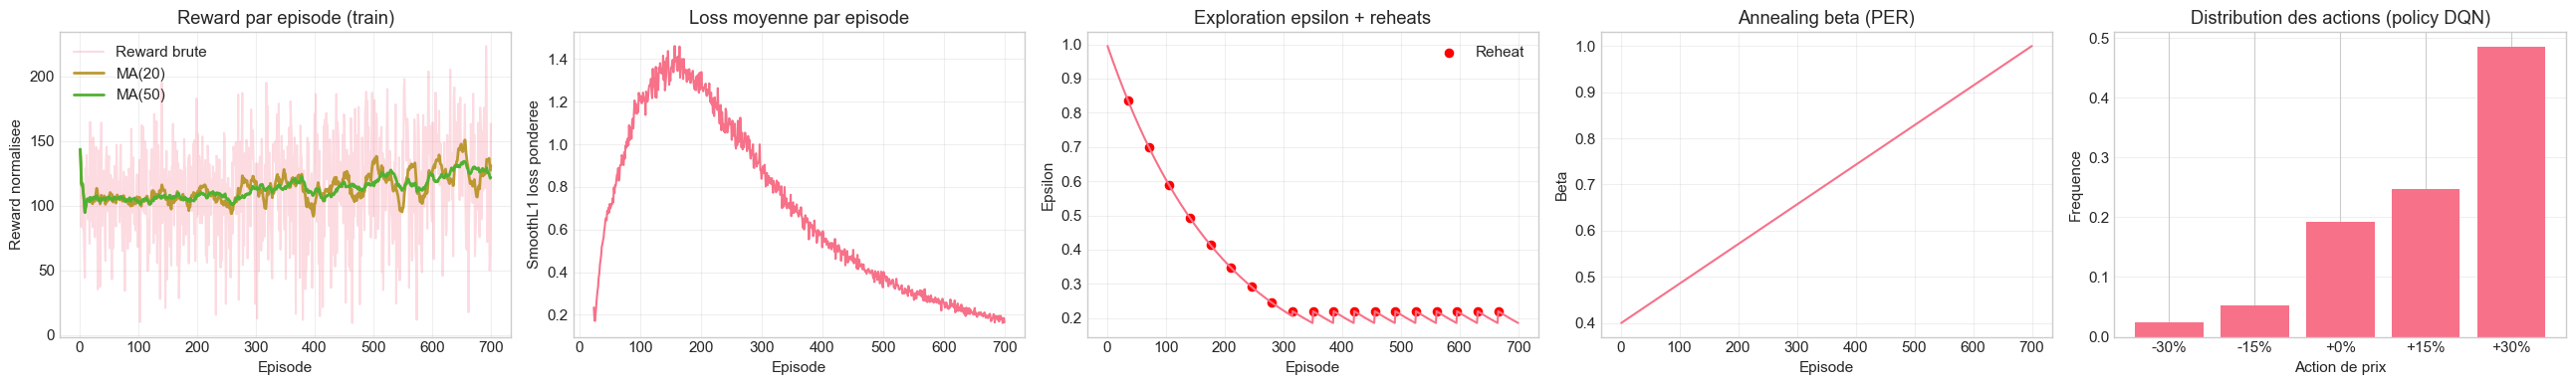


Apercu recommandations policy DQN:


,step,action_pct,new_price,realized_demand,gross_profit,raw_reward,scaled_reward
0,0,15.000001,136.850001,284.538126,10513.683942,5246.280812,0.655785
1,1,15.000001,110.940501,15.000000,1168.687516,546.496672,0.068312
2,2,30.000002,139.048392,133.703190,10837.765640,5245.675435,0.655709
3,3,15.000001,169.083391,400.473122,44489.917305,21833.714546,2.729214
4,4,30.000002,150.085047,2.464040,290.473485,120.430479,0.015054
5,5,30.000002,135.734338,168.218729,17277.129570,8264.308537,1.033039
6,6,30.000002,124.540785,190.072127,17394.029608,8423.537662,1.052942
7,7,30.000002,182.941814,328.745320,27299.607582,13506.429208,1.688304
8,8,30.000002,309.042617,202.856852,51130.600615,25212.236938,3.151530
9,9,30.000002,269.128044,0.780000,178.797874,-62.966889,-0.007871



Rapport d'adaptativite (actions selon buckets d'elasticite):


,elasticity_bucket,mean,median,count
0,"(-3.501, -2.085]",11.245622,15.000001,2569
1,"(-2.085, -1.112]",19.441089,30.000002,2648
2,"(-1.112, -0.2]",18.323712,30.000002,5023


action_pct,-30.000002,-15.000001,0.000000,15.000001,30.000002
elasticity_bucket,,,,,
"(-3.501, -2.085]",0.041261,0.113663,0.200467,0.343324,0.301285
"(-2.085, -1.112]",0.026057,0.038142,0.155211,0.174849,0.605740
"(-1.112, -0.2]",0.019510,0.016524,0.191519,0.267768,0.504678


In [32]:
# ------------------------------------------------------------------
# 6) Entrainement DQN avec exploration anti-plateau et PER coherent
# ------------------------------------------------------------------
def train_dqn(
    env: DynamicPricingEnv,
    agent: DQNAgent,
    replay_buffer: PrioritizedReplayBuffer,
    config: DQNConfig,
    episodes: int = 700,
    epsilon_start: float = 1.0,
    epsilon_end: float = 0.05,
    epsilon_decay: float = 0.995,
    reheat_epsilon: float = 0.22,
    plateau_window: int = 35,
    plateau_tolerance: float = 0.015,
):
    epsilon = epsilon_start
    best_ma = -np.inf
    stale_episodes = 0
    history = {
        'episode': [],
        'reward': [],
        'avg_loss': [],
        'epsilon': [],
        'beta': [],
        'reheat': [],
    }

    for ep in trange(1, episodes + 1, desc="Training DQN"):
        beta = config.per_beta_start + (config.per_beta_end - config.per_beta_start) * ((ep - 1) / max(1, episodes - 1))
        state = env.reset()
        done = False
        ep_reward = 0.0
        losses = []

        while not done:
            action = agent.act(state, epsilon)
            next_state, reward, done, _ = env.step(action)
            replay_buffer.push(state, action, reward, next_state, done)

            loss = agent.learn(replay_buffer, beta=beta)
            if loss is not None:
                losses.append(loss)

            state = next_state
            ep_reward += reward

        epsilon = max(epsilon_end, epsilon * epsilon_decay)
        recent_rewards = history['reward'][-(plateau_window - 1):] + [ep_reward]
        rolling_reward = float(np.mean(recent_rewards))
        reheated = 0

        if rolling_reward > best_ma + plateau_tolerance:
            best_ma = rolling_reward
            stale_episodes = 0
        else:
            stale_episodes += 1

        if stale_episodes >= plateau_window:
            epsilon = max(epsilon, reheat_epsilon)
            stale_episodes = 0
            reheated = 1

        history['episode'].append(ep)
        history['reward'].append(ep_reward)
        history['avg_loss'].append(float(np.mean(losses)) if losses else np.nan)
        history['epsilon'].append(epsilon)
        history['beta'].append(beta)
        history['reheat'].append(reheated)

    history_df = pd.DataFrame(history)
    history_df['reward_ma20'] = history_df['reward'].rolling(20, min_periods=1).mean()
    history_df['reward_ma50'] = history_df['reward'].rolling(50, min_periods=1).mean()
    return history_df


def make_eval_start_indices(env: DynamicPricingEnv, n_episodes: int, seed: int = 42) -> np.ndarray:
    rng = np.random.default_rng(seed)
    return rng.integers(0, env.max_start_index, size=n_episodes, dtype=np.int64)


def evaluate_policy(
    env: DynamicPricingEnv,
    agent: DQNAgent,
    n_episodes: int = 100,
    random_policy: bool = False,
    start_indices: np.ndarray | None = None,
    seed: int = 42,
):
    ep_rewards = []
    action_counter = np.zeros(env.n_actions, dtype=np.int64)
    rng = np.random.default_rng(seed)

    if start_indices is not None and len(start_indices) != n_episodes:
        raise ValueError("start_indices doit avoir la meme longueur que n_episodes.")

    for ep in range(n_episodes):
        start_idx = None if start_indices is None else int(start_indices[ep])
        state = env.reset(start_idx=start_idx)
        done = False
        ep_reward = 0.0

        while not done:
            if random_policy:
                action = int(rng.integers(env.n_actions))
            else:
                action = agent.act(state, epsilon=0.0)
            action_counter[action] += 1

            state, reward, done, _ = env.step(action)
            ep_reward += reward

        ep_rewards.append(ep_reward)

    return {
        'mean_reward': float(np.mean(ep_rewards)),
        'std_reward': float(np.std(ep_rewards)),
        'median_reward': float(np.median(ep_rewards)),
        'all_rewards': np.array(ep_rewards, dtype=np.float64),
        'action_distribution': action_counter / action_counter.sum(),
    }


def bootstrap_ci_mean_diff(
    a: np.ndarray,
    b: np.ndarray,
    n_boot: int = 3000,
    seed: int = 42,
    paired: bool = False,
):
    rng = np.random.default_rng(seed)
    a = np.asarray(a, dtype=np.float64)
    b = np.asarray(b, dtype=np.float64)

    if paired:
        if len(a) != len(b):
            raise ValueError("Bootstrap apparie: a et b doivent avoir la meme longueur.")
        diffs = a - b
        boot = np.empty(n_boot, dtype=np.float64)
        for i in range(n_boot):
            idx = rng.integers(0, len(diffs), len(diffs))
            boot[i] = diffs[idx].mean()
        ci_low, ci_high = np.percentile(boot, [2.5, 97.5])
        return float(ci_low), float(ci_high)

    boot = np.empty(n_boot, dtype=np.float64)
    for i in range(n_boot):
        a_s = a[rng.integers(0, len(a), len(a))]
        b_s = b[rng.integers(0, len(b), len(b))]
        boot[i] = a_s.mean() - b_s.mean()

    ci_low, ci_high = np.percentile(boot, [2.5, 97.5])
    return float(ci_low), float(ci_high)


TRAIN_EPISODES = 700
EPSILON_START = 1.0
EPSILON_END = 0.05
EPSILON_DECAY = 0.995
REHEAT_EPSILON = 0.22
PLATEAU_WINDOW = 35
PLATEAU_TOLERANCE = 0.015

print("Hyperparametres d'apprentissage DQN:")
print(f"  Learning rate     : {config.lr}")
print(f"  Discount factor   : {config.gamma}")
print(
    f"  Epsilon-greedy    : start={EPSILON_START}, end={EPSILON_END}, decay={EPSILON_DECAY}, reheat={REHEAT_EPSILON}"
)
print(f"  Batch size        : {config.batch_size}")
print(f"  Target soft update: tau={config.tau}")

history_df = train_dqn(
    env=train_env,
    agent=agent,
    replay_buffer=replay_buffer,
    config=config,
    episodes=TRAIN_EPISODES,
    epsilon_start=EPSILON_START,
    epsilon_end=EPSILON_END,
    epsilon_decay=EPSILON_DECAY,
    reheat_epsilon=REHEAT_EPSILON,
    plateau_window=PLATEAU_WINDOW,
    plateau_tolerance=PLATEAU_TOLERANCE,
)

print("Training termine.")
print(history_df.tail(5))
print(f"Nombre de reheats exploration: {int(history_df['reheat'].sum())}")


# ------------------------------------------------------------------
# 7) Evaluation principale sur memes points de depart
# ------------------------------------------------------------------
main_eval_starts = make_eval_start_indices(test_env, n_episodes=100, seed=SEED)
eval_dqn = evaluate_policy(
    test_env,
    agent,
    n_episodes=100,
    random_policy=False,
    start_indices=main_eval_starts,
    seed=SEED,
 )
eval_random = evaluate_policy(
    test_env,
    agent,
    n_episodes=100,
    random_policy=True,
    start_indices=main_eval_starts,
    seed=SEED + 123,
 )

ci_low, ci_high = bootstrap_ci_mean_diff(
    eval_dqn['all_rewards'],
    eval_random['all_rewards'],
    n_boot=3000,
    seed=SEED,
    paired=True,
 )

print("\n=== RESULTATS TEST (reward normalisee) ===")
print(f"DQN    -> mean: {eval_dqn['mean_reward']:.4f} | median: {eval_dqn['median_reward']:.4f} | std: {eval_dqn['std_reward']:.4f}")
print(f"Random -> mean: {eval_random['mean_reward']:.4f} | median: {eval_random['median_reward']:.4f} | std: {eval_random['std_reward']:.4f}")
print(f"IC95% apparie du gain moyen (DQN - Random): [{ci_low:.4f}, {ci_high:.4f}]")

if eval_random['mean_reward'] != 0:
    improvement = 100.0 * (eval_dqn['mean_reward'] - eval_random['mean_reward']) / abs(eval_random['mean_reward'])
    print(f"Gain relatif DQN vs Random: {improvement:.2f}%")

fig, axes = plt.subplots(1, 5, figsize=(26, 4))

axes[0].plot(history_df['episode'], history_df['reward'], alpha=0.25, label='Reward brute')
axes[0].plot(history_df['episode'], history_df['reward_ma20'], linewidth=2, label='MA(20)')
axes[0].plot(history_df['episode'], history_df['reward_ma50'], linewidth=2, label='MA(50)')
axes[0].set_title('Reward par episode (train)')
axes[0].set_xlabel('Episode')
axes[0].set_ylabel('Reward normalisee')
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(history_df['episode'], history_df['avg_loss'])
axes[1].set_title('Loss moyenne par episode')
axes[1].set_xlabel('Episode')
axes[1].set_ylabel('SmoothL1 loss ponderee')
axes[1].grid(alpha=0.3)

axes[2].plot(history_df['episode'], history_df['epsilon'])
reheat_points = history_df.loc[history_df['reheat'] == 1, 'episode']
reheat_values = history_df.loc[history_df['reheat'] == 1, 'epsilon']
if len(reheat_points) > 0:
    axes[2].scatter(reheat_points, reheat_values, color='red', s=35, label='Reheat')
    axes[2].legend()
axes[2].set_title('Exploration epsilon + reheats')
axes[2].set_xlabel('Episode')
axes[2].set_ylabel('Epsilon')
axes[2].grid(alpha=0.3)

axes[3].plot(history_df['episode'], history_df['beta'])
axes[3].set_title('Annealing beta (PER)')
axes[3].set_xlabel('Episode')
axes[3].set_ylabel('Beta')
axes[3].grid(alpha=0.3)

axes[4].bar(np.arange(len(action_multipliers)), eval_dqn['action_distribution'])
axes[4].set_xticks(np.arange(len(action_multipliers)))
axes[4].set_xticklabels([f"{int(a*100):+d}%" for a in action_multipliers], rotation=0)
axes[4].set_title('Distribution des actions (policy DQN)')
axes[4].set_xlabel('Action de prix')
axes[4].set_ylabel('Frequence')
axes[4].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


# ------------------------------------------------------------------
# 8) Exemple de recommandations de prix sur mini-echantillon test
# ------------------------------------------------------------------
def sample_policy_recommendations(env: DynamicPricingEnv, agent: DQNAgent, n_steps: int = 20, seed: int = 42):
    rows = []
    start_idx = int(make_eval_start_indices(env, n_episodes=1, seed=seed)[0])
    state = env.reset(start_idx=start_idx)

    for step in range(n_steps):
        action = agent.act(state, epsilon=0.0)
        next_state, _, done, info = env.step(action)

        rows.append({
            'step': step,
            'action_pct': float(env.action_multipliers[action] * 100.0),
            'new_price': info['new_price'],
            'realized_demand': info['realized_demand'],
            'gross_profit': info['gross_profit'],
            'raw_reward': info['raw_reward'],
            'scaled_reward': info['scaled_reward'],
        })

        state = next_state
        if done:
            break

    return pd.DataFrame(rows)


def action_adaptivity_report(
    env: DynamicPricingEnv,
    agent: DQNAgent,
    n_episodes: int = 80,
    seed: int = 777,
):
    start_indices = make_eval_start_indices(env, n_episodes=n_episodes, seed=seed)
    rows = []

    for start_idx in start_indices:
        state = env.reset(start_idx=int(start_idx))
        done = False

        while not done:
            action = agent.act(state, epsilon=0.0)
            next_state, _, done, info = env.step(action)
            rows.append({
                'action_id': int(action),
                'action_pct': float(env.action_multipliers[action] * 100.0),
                'elasticity': float(info['elasticity']),
                'overpricing_ratio': float(info['overpricing_ratio']),
            })
            state = next_state

    action_log = pd.DataFrame(rows)
    if action_log.empty:
        return action_log, pd.DataFrame(), pd.DataFrame()

    action_log['elasticity_bucket'] = pd.qcut(action_log['elasticity'], q=4, duplicates='drop')
    by_bucket = (
        action_log.groupby('elasticity_bucket')['action_pct']
        .agg(['mean', 'median', 'count'])
        .reset_index()
    )
    pivot = pd.crosstab(
        action_log['elasticity_bucket'],
        action_log['action_pct'],
        normalize='index',
    ).sort_index(axis=1)

    return action_log, by_bucket, pivot


recommendations = sample_policy_recommendations(test_env, agent, n_steps=20, seed=SEED + 99)
print("\nApercu recommandations policy DQN:")
display(recommendations.head(10))

adapt_log, adapt_summary, adapt_pivot = action_adaptivity_report(test_env, agent, n_episodes=80, seed=SEED + 55)
print("\nRapport d'adaptativite (actions selon buckets d'elasticite):")
display(adapt_summary)
display(adapt_pivot)

In [33]:
# ------------------------------------------------------------------
# 9) Audit anti-triche de l'environnement RL (version robuste)
# ------------------------------------------------------------------
import copy


def evaluate_constant_policy(
    env: DynamicPricingEnv,
    action_id: int,
    n_episodes: int = 100,
    start_indices: np.ndarray | None = None,
):
    ep_rewards = []

    if start_indices is not None and len(start_indices) != n_episodes:
        raise ValueError("start_indices doit avoir la meme longueur que n_episodes.")

    for ep in range(n_episodes):
        start_idx = None if start_indices is None else int(start_indices[ep])
        _ = env.reset(start_idx=start_idx)
        done = False
        ep_reward = 0.0
        while not done:
            _, reward, done, _ = env.step(action_id)
            ep_reward += reward
        ep_rewards.append(ep_reward)

    ep_rewards = np.array(ep_rewards, dtype=np.float64)
    return {
        "mean_reward": float(ep_rewards.mean()),
        "std_reward": float(ep_rewards.std()),
        "median_reward": float(np.median(ep_rewards)),
        "all_rewards": ep_rewards,
        "name": env.action_name(action_id),
    }


def one_step_action_dominance(
    env: DynamicPricingEnv,
    n_samples: int = 300,
    start_indices: np.ndarray | None = None,
):
    """
    Mesure si une action domine artificiellement a 1 pas.
    On clone l'env pour evaluer toutes les actions sur exactement les memes etats.
    """
    best_actions = []
    all_rewards = []

    if start_indices is not None and len(start_indices) != n_samples:
        raise ValueError("start_indices doit avoir la meme longueur que n_samples.")

    for i in range(n_samples):
        start_idx = None if start_indices is None else int(start_indices[i])
        _ = env.reset(start_idx=start_idx)
        rewards = []
        for a in range(env.n_actions):
            e_tmp = copy.deepcopy(env)
            _, r, _, _ = e_tmp.step(a)
            rewards.append(r)

        rewards = np.array(rewards, dtype=np.float64)
        best_actions.append(int(np.argmax(rewards)))
        all_rewards.append(rewards)

    best_actions = np.array(best_actions, dtype=np.int64)
    all_rewards = np.vstack(all_rewards)

    dominance = {
        int(a): float((best_actions == a).mean())
        for a in range(env.n_actions)
    }
    mean_reward_by_action = {
        int(a): float(all_rewards[:, a].mean())
        for a in range(env.n_actions)
    }
    return dominance, mean_reward_by_action, all_rewards


audit_n_episodes = 120
audit_start_indices = make_eval_start_indices(test_env, n_episodes=audit_n_episodes, seed=SEED + 7)
audit_eval_dqn = evaluate_policy(
    test_env,
    agent,
    n_episodes=audit_n_episodes,
    random_policy=False,
    start_indices=audit_start_indices,
    seed=SEED + 7,
 )
audit_eval_random = evaluate_policy(
    test_env,
    agent,
    n_episodes=audit_n_episodes,
    random_policy=True,
    start_indices=audit_start_indices,
    seed=SEED + 8,
 )

# Test A) DQN vs politiques constantes sur exactement les memes points de depart
const_results = {}
for a in range(test_env.n_actions):
    const_results[a] = evaluate_constant_policy(
        test_env,
        a,
        n_episodes=audit_n_episodes,
        start_indices=audit_start_indices,
    )

const_df = pd.DataFrame([
    {
        "action_id": a,
        "action": result["name"],
        "mean_reward": result["mean_reward"],
        "median_reward": result["median_reward"],
        "std_reward": result["std_reward"],
        "gap_vs_dqn": audit_eval_dqn["mean_reward"] - result["mean_reward"],
    }
    for a, result in const_results.items()
]).sort_values("mean_reward", ascending=False).reset_index(drop=True)

best_const_action = int(const_df.iloc[0]["action_id"])
best_const_eval = const_results[best_const_action]

dqn_vs_best_const_ci_low, dqn_vs_best_const_ci_high = bootstrap_ci_mean_diff(
    audit_eval_dqn["all_rewards"],
    best_const_eval["all_rewards"],
    n_boot=3000,
    seed=SEED + 21,
    paired=True,
)
paired_gain = audit_eval_dqn["all_rewards"] - best_const_eval["all_rewards"]
paired_win_rate = float((paired_gain > 0).mean())

# Test B) Dominance d'une action unique en contre-factuel 1-step
dominance_start_indices = make_eval_start_indices(test_env, n_episodes=350, seed=SEED + 11)
dominance, mean_one_step_reward, one_step_rewards = one_step_action_dominance(
    test_env,
    n_samples=350,
    start_indices=dominance_start_indices,
)
dominance_df = pd.DataFrame(
    [
        {
            "action_id": k,
            "action": test_env.action_name(k),
            "best_action_share": dominance[k],
            "mean_counterfactual_reward": mean_one_step_reward[k],
        }
        for k in range(test_env.n_actions)
    ]
).sort_values(["best_action_share", "mean_counterfactual_reward"], ascending=False).reset_index(drop=True)

# Test C) Signal economique attendu: hausse prix -> baisse demande (en moyenne)
signal_start_indices = make_eval_start_indices(test_env, n_episodes=300, seed=SEED + 13)
mc_env = copy.deepcopy(test_env)
price_delta = []
demand_delta = []

for start_idx in signal_start_indices:
    _ = mc_env.reset(start_idx=int(start_idx))

    e_down = copy.deepcopy(mc_env)
    _, _, _, info_down = e_down.step(0)

    e_up = copy.deepcopy(mc_env)
    _, _, _, info_up = e_up.step(4)

    price_delta.append(info_up["new_price"] - info_down["new_price"])
    demand_delta.append(info_up["realized_demand"] - info_down["realized_demand"])

price_delta = np.array(price_delta)
demand_delta = np.array(demand_delta)
neg_demand_when_price_up_share = float((demand_delta < 0).mean())

print("\n=== AUDIT ANTI-TRICHE ENVIRONNEMENT (ROBUSTE) ===")
print(f"DQN mean reward test principal : {eval_dqn['mean_reward']:.4f}")
print(f"Random mean reward principal   : {eval_random['mean_reward']:.4f}")
print(f"DQN mean reward audit         : {audit_eval_dqn['mean_reward']:.4f}")
print(f"Random mean reward audit      : {audit_eval_random['mean_reward']:.4f}")

print("\nTop politiques constantes (audit, memes starts que le DQN):")
display(const_df)

print("\nResume explicite des politiques constantes:")
const_df_by_action = const_df.sort_values("action_id").reset_index(drop=True)
for _, row in const_df_by_action.iterrows():
    print(
        f"Action {int(row['action_id'])} ({row['action']}) -> "
        f"mean={row['mean_reward']:.4f}, median={row['median_reward']:.4f}, std={row['std_reward']:.4f}"
    )

print(
    f"\nMeilleure politique constante: action {best_const_action} "
    f"({best_const_eval['name']}) -> mean={best_const_eval['mean_reward']:.4f}"
)
print(
    f"Gain moyen DQN - meilleure constante: {audit_eval_dqn['mean_reward'] - best_const_eval['mean_reward']:.4f}"
)
print(
    f"IC95% apparie du gain moyen DQN - meilleure constante: [{dqn_vs_best_const_ci_low:.4f}, {dqn_vs_best_const_ci_high:.4f}]"
)
print(f"Taux d'episodes ou DQN > meilleure constante: {paired_win_rate:.3f}")

print("\nDominance contre-factuelle des actions (1-step):")
display(dominance_df)

top_dom_action = int(dominance_df.iloc[0]["action_id"])
top_dom_share = float(dominance_df.iloc[0]["best_action_share"])
print(
    f"Action la plus dominante a 1-step: {test_env.action_name(top_dom_action)} "
    f"(share={top_dom_share:.3f})"
)

print("\nCohérence economique (hausse prix -> baisse demande):")
print(f"Part des cas ou demande_up - demande_down < 0 : {neg_demand_when_price_up_share:.3f}")

# Verdict automatique
cheat_flags = []
if dqn_vs_best_const_ci_low <= 0:
    cheat_flags.append("DQN_pas_significativement_mieux_que_constante")
if top_dom_share >= 0.70:
    cheat_flags.append("Action_unique_dominante")
if neg_demand_when_price_up_share < 0.65:
    cheat_flags.append("Demande_pas_assez_sensible_au_prix")

print("\nVerdict:")
if cheat_flags:
    print("Risque de triche/sur-optimisme detecte ->", cheat_flags)
else:
    print("Audit passe: le DQN reste au-dessus de la meilleure politique constante, sans action unique dominante evidente, avec un signal prix-demande coherent.")


=== AUDIT ANTI-TRICHE ENVIRONNEMENT (ROBUSTE) ===
DQN mean reward test principal : 155.5493
Random mean reward principal   : 117.4701
DQN mean reward audit         : 155.1751
Random mean reward audit      : 116.9768

Top politiques constantes (audit, memes starts que le DQN):


,action_id,action,mean_reward,median_reward,std_reward,gap_vs_dqn
0,3,INCREASE_SMALL (+15%),149.937542,148.597122,24.293351,5.237582
1,4,INCREASE_LARGE (+30%),149.649248,148.912640,28.192932,5.525876
2,2,MAINTAIN (0%),128.529790,126.128848,24.741811,26.645334
3,1,DECREASE_SMALL (-15%),78.953414,76.031358,25.548040,76.221710
4,0,DECREASE_LARGE (-30%),7.792098,6.991060,25.506226,147.383026



Resume explicite des politiques constantes:
Action 0 (DECREASE_LARGE (-30%)) -> mean=7.7921, median=6.9911, std=25.5062
Action 1 (DECREASE_SMALL (-15%)) -> mean=78.9534, median=76.0314, std=25.5480
Action 2 (MAINTAIN (0%)) -> mean=128.5298, median=126.1288, std=24.7418
Action 3 (INCREASE_SMALL (+15%)) -> mean=149.9375, median=148.5971, std=24.2934
Action 4 (INCREASE_LARGE (+30%)) -> mean=149.6492, median=148.9126, std=28.1929

Meilleure politique constante: action 3 (INCREASE_SMALL (+15%)) -> mean=149.9375
Gain moyen DQN - meilleure constante: 5.2376
IC95% apparie du gain moyen DQN - meilleure constante: [4.2354, 6.2357]
Taux d'episodes ou DQN > meilleure constante: 0.792

Dominance contre-factuelle des actions (1-step):


,action_id,action,best_action_share,mean_counterfactual_reward
0,4,INCREASE_LARGE (+30%),0.657143,1.039541
1,3,INCREASE_SMALL (+15%),0.168571,1.010718
2,0,DECREASE_LARGE (-30%),0.082857,0.541815
3,2,MAINTAIN (0%),0.054286,0.936428
4,1,DECREASE_SMALL (-15%),0.037143,0.798039


Action la plus dominante a 1-step: INCREASE_LARGE (+30%) (share=0.657)

Cohérence economique (hausse prix -> baisse demande):
Part des cas ou demande_up - demande_down < 0 : 1.000

Verdict:
Audit passe: le DQN reste au-dessus de la meilleure politique constante, sans action unique dominante evidente, avec un signal prix-demande coherent.


In [34]:
# Vérification des politiques constantes sur les mêmes starts
n_eval = 120
starts = make_eval_start_indices(test_env, n_episodes=n_eval, seed=SEED + 7)

const_scores = {}
for action_id in range(test_env.n_actions):
    out = evaluate_constant_policy(
        test_env,
        action_id=action_id,
        n_episodes=n_eval,
        start_indices=starts
    )
    const_scores[action_id] = out["mean_reward"]

print(f"Action -30% -> {const_scores[0]:.4f}")
print(f"Action -15% -> {const_scores[1]:.4f}")
print(f"Action 0%   -> {const_scores[2]:.4f}")
print(f"Action +15% -> {const_scores[3]:.4f}")
print(f"Action +30% -> {const_scores[4]:.4f}")

Action -30% -> 7.7921
Action -15% -> 78.9534
Action 0%   -> 128.5298
Action +15% -> 149.9375
Action +30% -> 149.6492


## 10) Évaluation & interprétation (niveau master)
- Validation temporelle hors entraînement
- Robustesse sous stress business (forte demande, faible stock)
- Interprétation de la stratégie via règles et graphes prix vs demande


=== PERFORMANCE SUR VALIDATION ET TEST (meme protocole) ===


,split,dqn_mean,random_mean,dqn_minus_random,ci95_low,ci95_high
0,validation,156.468044,119.802022,36.666023,33.828314,39.503721
1,test,155.123020,113.779457,41.343563,39.023927,43.570865



=== ROBUSTESSE SOUS STRESS BUSINESS ===


,scenario,dqn_mean,random_mean,dqn_minus_random,ci95_low,ci95_high,dqn_std
3,high_demand_plus_low_stock,164.629007,104.919577,59.709429,56.953540,62.747626,25.928615
2,low_stock,147.275262,91.586363,55.688899,52.455096,58.935035,20.479182
1,high_demand,176.603960,129.629875,46.974085,44.514963,49.505006,21.773493
0,baseline,155.747365,113.402001,42.345364,39.671291,45.029215,22.578606



=== REGLES EXTRAITES DE LA STRATEGIE DQN ===
Correlation(new_price, realized_demand): 0.1200
Correlation(new_price, gross_profit): 0.4558

Regles par deciles de prix:


,price_bin,mean_demand,mean_action_pct,mean_profit,n
0,"(7.955, 89.318]",153.628968,9.908855,3617.354653,1152
1,"(89.318, 110.981]",147.602268,15.091147,6982.326885,1152
2,"(110.981, 127.45]",163.024016,16.445314,10341.740775,1152
3,"(127.45, 143.924]",161.823307,17.486980,13333.537623,1152
4,"(143.924, 160.642]",172.077326,19.309897,16749.135892,1152
5,"(160.642, 178.674]",193.847580,19.453126,21626.364169,1152
6,"(178.674, 200.016]",195.625691,20.125760,25957.264616,1153
7,"(200.016, 228.814]",219.073109,19.404867,34472.110158,1151
8,"(228.814, 287.803]",252.321273,19.674480,48919.754805,1152
9,"(287.803, 1942.475]",248.030764,19.648439,85000.370753,1152



Regles par quartiles d'elasticite:


,elasticity_bin,mean_action_pct,pct_price_increase,mean_demand,n
0,"(-3.501, -1.923]",11.271386,0.628313,194.492696,2981
1,"(-1.923, -1.097]",21.026972,0.797718,167.238053,2892
2,"(-1.097, -0.2]",19.297858,0.796529,200.720370,5647


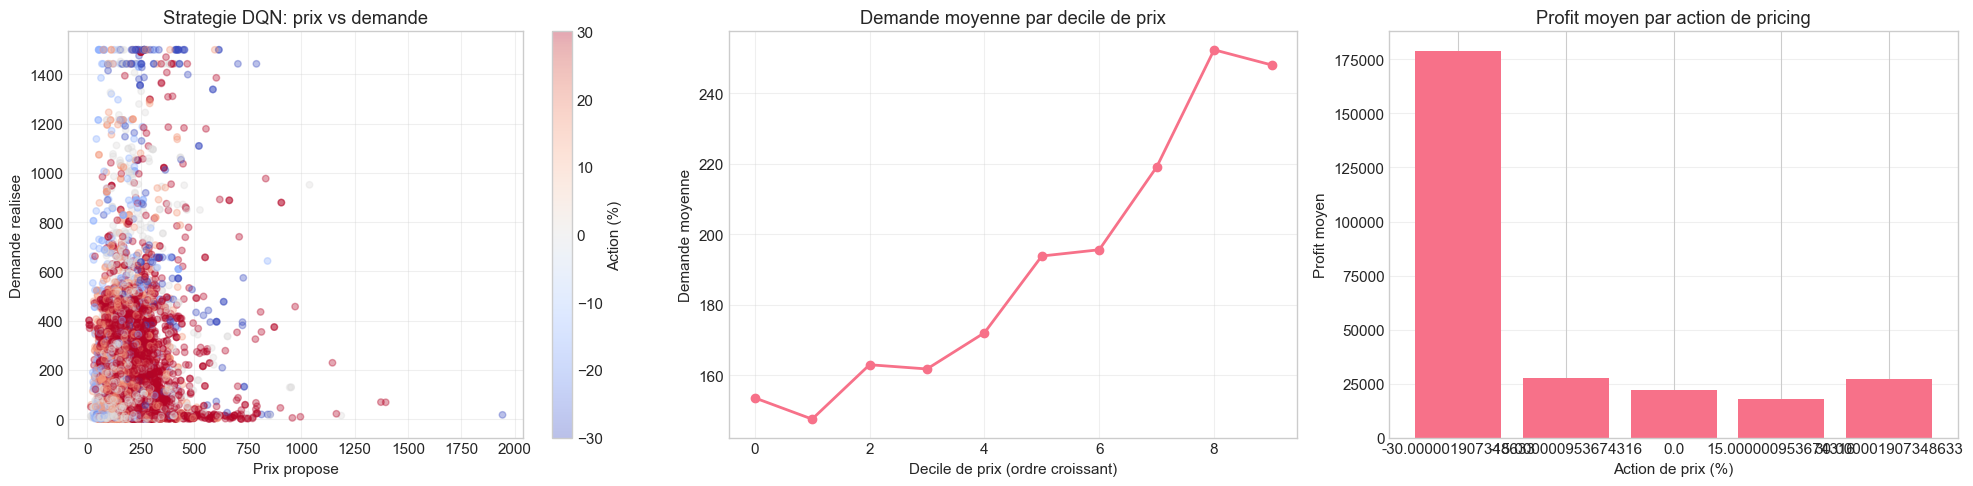


Conclusion robuste:
- Validation: verifier que l'IC95% de (DQN - Random) reste > 0.
- Stress-tests: verifier que le gap DQN-Random reste positif dans chaque scenario.
- Interpretation: confirmer la decroissance demande-prix et la logique d'action selon elasticite.


In [35]:
# ------------------------------------------------------------------
# 10) Evaluation avancee: validation, robustesse, interpretation
# ------------------------------------------------------------------

def clone_env_with_data(base_env: DynamicPricingEnv, data: pd.DataFrame, seed: int) -> DynamicPricingEnv:
    """Clone la configuration de l'env de reference sur un nouveau jeu de donnees."""
    return DynamicPricingEnv(
        data=data.reset_index(drop=True),
        scaler=base_env.scaler,
        state_cols=base_env.state_cols,
        action_multipliers=base_env.action_multipliers,
        episode_len=base_env.episode_len,
        mean_reversion=base_env.mean_reversion,
        reward_scale=base_env.reward_scale,
        reward_clip=base_env.reward_clip,
        alpha_profit=base_env.alpha_profit,
        beta_satisfaction=base_env.beta_satisfaction,
        gamma_volatility=base_env.gamma_volatility,
        sat_score_threshold=base_env.sat_score_threshold,
        overprice_soft_cap=base_env.overprice_soft_cap,
        overprice_hard_cap=base_env.overprice_hard_cap,
        repeat_increase_penalty=base_env.repeat_increase_penalty,
        seed=seed,
    )


def build_temporal_val_test(df: pd.DataFrame, val_ratio: float = 0.15, test_ratio: float = 0.15):
    if val_ratio <= 0 or test_ratio <= 0 or (val_ratio + test_ratio) >= 1:
        raise ValueError("Les ratios val/test doivent etre > 0 et val_ratio + test_ratio < 1.")

    n = len(df)
    train_end = int((1.0 - val_ratio - test_ratio) * n)
    val_end = int((1.0 - test_ratio) * n)

    train_part = df.iloc[:train_end].reset_index(drop=True)
    val_part = df.iloc[train_end:val_end].reset_index(drop=True)
    test_part = df.iloc[val_end:].reset_index(drop=True)

    if len(val_part) < 200 or len(test_part) < 200:
        print("[Avertissement] Validation/test petits; les IC seront plus larges.")

    return train_part, val_part, test_part


def evaluate_vs_random(env: DynamicPricingEnv, agent: DQNAgent, n_episodes: int, seed: int):
    starts = make_eval_start_indices(env, n_episodes=n_episodes, seed=seed)
    dqn = evaluate_policy(
        env,
        agent,
        n_episodes=n_episodes,
        random_policy=False,
        start_indices=starts,
        seed=seed,
    )
    rnd = evaluate_policy(
        env,
        agent,
        n_episodes=n_episodes,
        random_policy=True,
        start_indices=starts,
        seed=seed + 1,
    )
    ci_low, ci_high = bootstrap_ci_mean_diff(
        dqn["all_rewards"],
        rnd["all_rewards"],
        n_boot=3000,
        seed=seed + 2,
        paired=True,
    )
    return dqn, rnd, ci_low, ci_high


def rollout_trace(env: DynamicPricingEnv, agent: DQNAgent, n_episodes: int = 80, seed: int = 1234) -> pd.DataFrame:
    starts = make_eval_start_indices(env, n_episodes=n_episodes, seed=seed)
    rows = []

    for start_idx in starts:
        state = env.reset(start_idx=int(start_idx))
        done = False
        step = 0

        while not done:
            action = agent.act(state, epsilon=0.0)
            next_state, reward, done, info = env.step(action)

            rows.append({
                "episode_start": int(start_idx),
                "step": int(step),
                "action_id": int(action),
                "action_pct": float(env.action_multipliers[action] * 100.0),
                "new_price": float(info["new_price"]),
                "realized_demand": float(info["realized_demand"]),
                "gross_profit": float(info["gross_profit"]),
                "reward": float(reward),
                "elasticity": float(info["elasticity"]),
                "overpricing_ratio": float(info["overpricing_ratio"]),
            })

            state = next_state
            step += 1

    return pd.DataFrame(rows)


# 1) Validation temporelle stricte (hors train)
_, val_df_strict, test_df_strict = build_temporal_val_test(df_rl, val_ratio=0.15, test_ratio=0.15)
val_env = clone_env_with_data(test_env, val_df_strict, seed=SEED + 200)
test_env_strict = clone_env_with_data(test_env, test_df_strict, seed=SEED + 201)

val_dqn, val_rnd, val_ci_low, val_ci_high = evaluate_vs_random(val_env, agent, n_episodes=120, seed=SEED + 210)
tst_dqn, tst_rnd, tst_ci_low, tst_ci_high = evaluate_vs_random(test_env_strict, agent, n_episodes=120, seed=SEED + 220)

val_test_table = pd.DataFrame([
    {
        "split": "validation",
        "dqn_mean": val_dqn["mean_reward"],
        "random_mean": val_rnd["mean_reward"],
        "dqn_minus_random": val_dqn["mean_reward"] - val_rnd["mean_reward"],
        "ci95_low": val_ci_low,
        "ci95_high": val_ci_high,
    },
    {
        "split": "test",
        "dqn_mean": tst_dqn["mean_reward"],
        "random_mean": tst_rnd["mean_reward"],
        "dqn_minus_random": tst_dqn["mean_reward"] - tst_rnd["mean_reward"],
        "ci95_low": tst_ci_low,
        "ci95_high": tst_ci_high,
    },
])

print("\n=== PERFORMANCE SUR VALIDATION ET TEST (meme protocole) ===")
display(val_test_table)


# 2) Robustesse: forte demande / faible stock
stress_base = test_df_strict.copy()
stress_high_demand = test_df_strict.copy()
stress_low_stock = test_df_strict.copy()
stress_combo = test_df_strict.copy()

# Forte demande: +80% demande de base, elasticite legerement plus forte en valeur absolue
stress_high_demand["base_demand"] = (stress_high_demand["base_demand"] * 1.8).clip(lower=0.5, upper=1200.0)
stress_high_demand["elasticite_demande"] = (stress_high_demand["elasticite_demande"] * 1.10).clip(lower=-3.5, upper=-0.2)

# Faible stock (proxy): cout unitaire augmente et pression sur prix de reference
stress_low_stock["estimated_unit_cost"] = (
    stress_low_stock["estimated_unit_cost"] * 1.25
).clip(lower=1.0, upper=0.98 * stress_low_stock["price"])
stress_low_stock["historical_ref_price"] = (stress_low_stock["historical_ref_price"] * 1.10).clip(lower=1.0)

# Stress combine
stress_combo["base_demand"] = (stress_combo["base_demand"] * 1.8).clip(lower=0.5, upper=1200.0)
stress_combo["elasticite_demande"] = (stress_combo["elasticite_demande"] * 1.10).clip(lower=-3.5, upper=-0.2)
stress_combo["estimated_unit_cost"] = (
    stress_combo["estimated_unit_cost"] * 1.25
).clip(lower=1.0, upper=0.98 * stress_combo["price"])
stress_combo["historical_ref_price"] = (stress_combo["historical_ref_price"] * 1.10).clip(lower=1.0)

stress_envs = {
    "baseline": clone_env_with_data(test_env, stress_base, seed=SEED + 300),
    "high_demand": clone_env_with_data(test_env, stress_high_demand, seed=SEED + 301),
    "low_stock": clone_env_with_data(test_env, stress_low_stock, seed=SEED + 302),
    "high_demand_plus_low_stock": clone_env_with_data(test_env, stress_combo, seed=SEED + 303),
}

stress_rows = []
for i, (name, env_s) in enumerate(stress_envs.items()):
    dqn_s, rnd_s, ci_l, ci_h = evaluate_vs_random(env_s, agent, n_episodes=100, seed=SEED + 310 + i)
    stress_rows.append({
        "scenario": name,
        "dqn_mean": dqn_s["mean_reward"],
        "random_mean": rnd_s["mean_reward"],
        "dqn_minus_random": dqn_s["mean_reward"] - rnd_s["mean_reward"],
        "ci95_low": ci_l,
        "ci95_high": ci_h,
        "dqn_std": dqn_s["std_reward"],
    })

stress_df = pd.DataFrame(stress_rows).sort_values("dqn_minus_random", ascending=False)
print("\n=== ROBUSTESSE SOUS STRESS BUSINESS ===")
display(stress_df)


# 3) Interpretation: regles + graphes prix vs demande
trace_df = rollout_trace(test_env_strict, agent, n_episodes=90, seed=SEED + 400)
if trace_df.empty:
    raise RuntimeError("Trace vide: impossible de produire les graphes d'interpretation.")

trace_df["price_bin"] = pd.qcut(trace_df["new_price"], q=10, duplicates="drop")
trace_df["elasticity_bin"] = pd.qcut(trace_df["elasticity"], q=4, duplicates="drop")

rules_price = (
    trace_df.groupby("price_bin", observed=False)
    .agg(
        mean_demand=("realized_demand", "mean"),
        mean_action_pct=("action_pct", "mean"),
        mean_profit=("gross_profit", "mean"),
        n=("action_id", "size"),
    )
    .reset_index()
)

rules_elasticity = (
    trace_df.groupby("elasticity_bin", observed=False)
    .agg(
        mean_action_pct=("action_pct", "mean"),
        pct_price_increase=("action_pct", lambda s: float((s > 0).mean())),
        mean_demand=("realized_demand", "mean"),
        n=("action_id", "size"),
    )
    .reset_index()
)

corr_price_demand = float(trace_df["new_price"].corr(trace_df["realized_demand"]))
corr_price_profit = float(trace_df["new_price"].corr(trace_df["gross_profit"]))

print("\n=== REGLES EXTRAITES DE LA STRATEGIE DQN ===")
print(f"Correlation(new_price, realized_demand): {corr_price_demand:.4f}")
print(f"Correlation(new_price, gross_profit): {corr_price_profit:.4f}")
print("\nRegles par deciles de prix:")
display(rules_price)
print("\nRegles par quartiles d'elasticite:")
display(rules_elasticity)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Graphe 1: nuage prix vs demande
scatter = axes[0].scatter(
    trace_df["new_price"],
    trace_df["realized_demand"],
    c=trace_df["action_pct"],
    cmap="coolwarm",
    alpha=0.35,
    s=22,
)
axes[0].set_title("Strategie DQN: prix vs demande")
axes[0].set_xlabel("Prix propose")
axes[0].set_ylabel("Demande realisee")
axes[0].grid(alpha=0.3)
cbar = plt.colorbar(scatter, ax=axes[0])
cbar.set_label("Action (%)")

# Graphe 2: demande moyenne par decile de prix
axes[1].plot(
    rules_price.index,
    rules_price["mean_demand"],
    marker="o",
    linewidth=2,
)
axes[1].set_title("Demande moyenne par decile de prix")
axes[1].set_xlabel("Decile de prix (ordre croissant)")
axes[1].set_ylabel("Demande moyenne")
axes[1].grid(alpha=0.3)

# Graphe 3: profit moyen par action de prix
profit_by_action = (
    trace_df.groupby("action_pct", as_index=False)["gross_profit"]
    .mean()
    .sort_values("action_pct")
)
axes[2].bar(profit_by_action["action_pct"].astype(str), profit_by_action["gross_profit"])
axes[2].set_title("Profit moyen par action de pricing")
axes[2].set_xlabel("Action de prix (%)")
axes[2].set_ylabel("Profit moyen")
axes[2].grid(alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

print("\nConclusion robuste:")
print("- Validation: verifier que l'IC95% de (DQN - Random) reste > 0.")
print("- Stress-tests: verifier que le gap DQN-Random reste positif dans chaque scenario.")
print("- Interpretation: confirmer la decroissance demande-prix et la logique d'action selon elasticite.")